# Per‑region Benth OU + Neural Networks (Model 1: NN calibration)

Your CSV has **many regions** (multiple rows per date). This notebook trains **one independent model per region**:

- Fit seasonal mean $s_r(t)$ (harmonic regression) for each region $r$
- Residuals $X_{r,t}=T_{r,t}-s_r(t)$
- Train a neural network that predicts $(\kappa_{r,t},\sigma_{r,t})$ from a rolling window and DOY features

Outputs per region:
- training / test NLL curves
- learned $\kappa_{r,t}$ and $\sigma_{r,t}$ over time
- standardized residual diagnostics
- optional Monte‑Carlo simulation + HDD example

**Note:** This is the "Model 1" approach (NN calibrates OU parameters).

In [57]:
# --- Imports ---
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from dataclasses import dataclass

np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

## 1) Load your CSV

Expected columns:
- `date`
- `region_code`
- `temp`

If your column names differ, rename them below.

In [58]:
CSV_PATH = "../EDA/region_avg.csv"  # <- change if needed
DATE_COL = "date"
REGION_COL = "region_code"
TEMP_COL = "daily_avg_temperature"

df_raw = pd.read_csv(CSV_PATH)
df_raw = df_raw.rename(columns={DATE_COL:"date", REGION_COL:"region_code", TEMP_COL:"daily_avg_temperature"})

df_raw["date"] = pd.to_datetime(df_raw["date"], errors="coerce")
df_raw["temp"] = pd.to_numeric(df_raw["daily_avg_temperature"], errors="coerce")
df_raw["region_code"] = pd.to_numeric(df_raw["region_code"], errors="coerce")

df_raw = df_raw.dropna(subset=["date","temp","region_code"]).copy()
df_raw["region_code"] = df_raw["region_code"].astype(int)

print(df_raw.head())
print(df_raw.tail())
print("shape:", df_raw.shape)
print("regions:", df_raw["region_code"].nunique())


        date  region_code  daily_avg_temperature  temp
0 1970-01-01           11                  -2.40 -2.40
1 1970-01-01           24                  -2.50 -2.50
2 1970-01-01           28                   4.40  4.40
3 1970-01-01           44                  -3.35 -3.35
4 1970-01-01           52                  -0.85 -0.85
             date  region_code  daily_avg_temperature      temp
158009 2024-12-31           28               5.875000  5.875000
158010 2024-12-31           32               4.795455  4.795455
158011 2024-12-31           44              -0.102632 -0.102632
158012 2024-12-31           52               5.662500  5.662500
158013 2024-12-31           53               8.276667  8.276667
shape: (151743, 4)
regions: 8


## 2) Helper functions

In [59]:
def design_matrix_seasonality(dates: pd.Series, K: int = 3, include_trend: bool = True) -> np.ndarray:
    n = len(dates)
    doy = dates.dt.dayofyear.values.astype(float)
    parts = [np.ones(n)]
    if include_trend:
        t = np.arange(n) / 365.0
        parts.append(t)
    for k in range(1, K+1):
        parts.append(np.sin(2*np.pi*k*doy/365.0))
        parts.append(np.cos(2*np.pi*k*doy/365.0))
    return np.column_stack(parts)

def fit_seasonal_mean(dates: pd.Series, temp: np.ndarray, K: int = 3):
    X = design_matrix_seasonality(dates, K=K, include_trend=True)
    y = temp.astype(float)
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    s_hat = X @ beta
    return s_hat, beta

def doy_features(dates: pd.Series, harmonics: int = 3) -> np.ndarray:
    doy = dates.dt.dayofyear.values.astype(float)
    feats = []
    for k in range(1, harmonics+1):
        feats.append(np.sin(2*np.pi*k*doy/365.0))
        feats.append(np.cos(2*np.pi*k*doy/365.0))
    return np.column_stack(feats)

def make_windows(x: np.ndarray, doy_feat: np.ndarray, window: int = 30):
    x = np.asarray(x, dtype=np.float32)
    doy_feat = np.asarray(doy_feat, dtype=np.float32)
    N, F = doy_feat.shape
    xs, xt, y, idx = [], [], [], []
    for t in range(window, N-1):
        inp = np.concatenate([x[t-window:t], doy_feat[t]], axis=0)
        xs.append(inp)
        xt.append(x[t])
        y.append(x[t+1])
        idx.append(t)
    return np.stack(xs), np.array(xt), np.array(y), np.array(idx)

class CalibNet(nn.Module):
    def __init__(self, in_dim: int, hidden: int = 64, kappa_max: float = 0.5):
        super().__init__()
        self.kappa_max = kappa_max
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 2),  # raw_kappa, raw_sigma
        )
        self.softplus = nn.Softplus()

    def forward(self, x):
        raw = self.net(x)
        kappa = self.kappa_max * torch.sigmoid(raw[:, 0]) + 1e-6
        sigma = self.softplus(raw[:, 1]) + 1e-6
        return kappa, sigma

def ou_nll_euler(x_t, x_tp1, kappa, sigma, dt: float = 1.0):
    mean = x_t - kappa * x_t * dt
    var = (sigma ** 2) * dt
    var = torch.clamp(var, min=1e-6)  # prevents log(0)/div0
    resid2 = (x_tp1 - mean) ** 2
    resid2 = torch.clamp(resid2, max=1e8)
    return 0.5 * (torch.log(var) + resid2 / var).mean()


## 3) Per‑region training configuration

In [60]:
# Model / data hyperparameters
K_HARMONICS = 3       # seasonal mean harmonics
DOY_HARMONICS = 3     # NN time-of-year features
WINDOW = 30           # rolling residual window length
DT = 1.0              # daily step
EPOCHS = 800          # increase if you want
LR = 1e-3
HIDDEN = 64
KAPPA_MAX = 0.5       # daily kappa bound

# Regions to train (edit if you want a subset)
regions = sorted(df_raw["region_code"].unique().tolist())
print("Total regions:", len(regions))
print("Regions:", regions)


Total regions: 8
Regions: [11, 24, 27, 28, 32, 44, 52, 53]


## 4) Train one model per region

This loop will:
1. Filter data to one region
2. Fit seasonal mean $s_r(t)$
3. Compute residuals $X_{r,t}$
4. Standardize residuals (stability)
5. Train CalibNet via OU likelihood
6. Save model weights + store diagnostics


In [ ]:
results = []              # summary rows
models = {}               # region -> model (in-memory)
region_artifacts = {}     # region -> dict of arrays for plots/diagnostics

OUT_DIR = "per_region_models"
os.makedirs(OUT_DIR, exist_ok=True)

for r in regions:
    dfr = df_raw[df_raw["region_code"] == r].sort_values("date").reset_index(drop=True)

    # Ensure one value per date for this region
    dfr = dfr.groupby("date", as_index=False)["temp"].mean()
    if len(dfr) < (WINDOW + 60):
        results.append({"region": r, "status":"skipped (too short)", "n_days": len(dfr)})
        continue

    # Fit seasonal mean and residuals
    s_hat, beta = fit_seasonal_mean(dfr["date"], dfr["temp"].values, K=K_HARMONICS)
    x = (dfr["temp"].values - s_hat).astype(np.float32)

    # Standardize residuals (important!)
    x_mean = float(np.mean(x))
    x_std  = float(np.std(x) + 1e-8)
    xz = (x - x_mean) / x_std

    # Build features/windows
    doy_feat = doy_features(dfr["date"], harmonics=DOY_HARMONICS)
    X_in, x_t, x_tp1, idx_t = make_windows(xz, doy_feat, window=WINDOW)

    # Date-based train/test split
    train_end_date = pd.Timestamp("2014-12-31")
    test_end_date = pd.Timestamp("2024-12-31")

    # idx_t contains the time index corresponding to x_t
    window_dates = dfr.loc[idx_t, "date"].reset_index(drop=True)

    train_mask = window_dates <= train_end_date
    test_mask = (window_dates > train_end_date) & (window_dates <= test_end_date)

    X_train = torch.tensor(X_in[train_mask.values], dtype=torch.float32, device=device)
    x_t_train = torch.tensor(x_t[train_mask.values], dtype=torch.float32, device=device)
    x_tp1_train = torch.tensor(x_tp1[train_mask.values], dtype=torch.float32, device=device)

    X_test = torch.tensor(X_in[test_mask.values], dtype=torch.float32, device=device)
    x_t_test = torch.tensor(x_t[test_mask.values], dtype=torch.float32, device=device)
    x_tp1_test = torch.tensor(x_tp1[test_mask.values], dtype=torch.float32, device=device)

    print(f"Region {r}: train={train_mask.sum()} obs, test={test_mask.sum()} obs")

    # Model
    model = CalibNet(in_dim=X_train.shape[1], hidden=HIDDEN, kappa_max=KAPPA_MAX).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=LR)

    # Train
    train_curve, test_curve, epochs_logged = [], [], []
    for epoch in range(1, EPOCHS+1):
        model.train()
        kappa, sigma = model(X_train)
        loss = ou_nll_euler(x_t_train, x_tp1_train, kappa, sigma, dt=DT)

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        if epoch % 50 == 0 or epoch == 1:
            model.eval()
            with torch.no_grad():
                k_te, s_te = model(X_test)
                loss_te = ou_nll_euler(x_t_test, x_tp1_test, k_te, s_te, dt=DT)
            train_curve.append(float(loss.item()))
            test_curve.append(float(loss_te.item()))
            epochs_logged.append(epoch)

    # Evaluate on all windows
    model.eval()
    with torch.no_grad():
        k_all, s_all = model(torch.tensor(X_in, dtype=torch.float32, device=device))
    k_all = k_all.detach().cpu().numpy()
    s_all = s_all.detach().cpu().numpy()

    # Standardized residuals on test
    with torch.no_grad():
        k_te, s_te = model(X_test)
        mean_te = x_t_test - k_te * x_t_test * DT
        z_te = (x_tp1_test - mean_te) / (s_te * np.sqrt(DT))
    z_te = z_te.detach().cpu().numpy()

    # Save model + region params needed to simulate back in original units
    save_path = os.path.join(OUT_DIR, f"calibnet_region_{r}.pt")
    torch.save({
        "state_dict": model.state_dict(),
        "window": WINDOW,
        "doy_harmonics": DOY_HARMONICS,
        "k_harmonics": K_HARMONICS,
        "beta": beta,
        "x_mean": x_mean,
        "x_std": x_std,
        "kappa_max": KAPPA_MAX,
        "hidden": HIDDEN,
    }, save_path)

    models[r] = model
    region_artifacts[r] = {
        "df": dfr,
        "beta": beta,
        "s_hat": s_hat,
        "x": x,            # original residual
        "xz": xz,          # standardized residual
        "idx_t": idx_t,
        "kappa_all": k_all,
        "sigma_all": s_all,
        "train_curve": train_curve,
        "test_curve": test_curve,
        "epochs_logged": epochs_logged,
        "z_test": z_te,
        "save_path": save_path,
    }

    results.append({
        "region": r,
        "status":"ok",
        "n_days": len(dfr),
        "train_nll_last": train_curve[-1] if len(train_curve) else np.nan,
        "test_nll_last": test_curve[-1] if len(test_curve) else np.nan,
        "z_mean": float(np.mean(z_te)),
        "z_std": float(np.std(z_te)),
        "model_path": save_path,
    })

summary = pd.DataFrame(results).sort_values(["status","region"])
summary.head(), summary.tail(), summary.shape


Region 11: train=16406 obs, test=3652 obs
Region 24: train=16406 obs, test=3652 obs
Region 27: train=11488 obs, test=3651 obs


### Summary table

In [ ]:
summary

,region,status,n_days,train_nll_last,test_nll_last,z_mean,z_std,model_path
0,11,ok,20089,-0.196047,0.686365,0.031003,1.659722,per_region_models/calibnet_region_11.pt
1,24,ok,20089,-0.199912,0.488393,0.001600,1.542472,per_region_models/calibnet_region_24.pt
2,27,ok,15170,-0.199707,0.777018,-0.003392,1.708630,per_region_models/calibnet_region_27.pt
3,28,ok,20089,-0.182981,0.532162,0.041876,1.552320,per_region_models/calibnet_region_28.pt
4,32,ok,16039,-0.221842,0.918502,0.030088,1.817543,per_region_models/calibnet_region_32.pt
5,44,ok,20089,-0.251788,0.257844,0.047088,1.399454,per_region_models/calibnet_region_44.pt
6,52,ok,20089,-0.141830,0.360824,0.046923,1.410453,per_region_models/calibnet_region_52.pt
7,53,ok,20089,-0.190447,0.377825,-0.003122,1.455926,per_region_models/calibnet_region_53.pt


In [8]:
# ============================================================
# GRID SEARCH FOR NN ARCHITECTURE
# Uses the ORIGINAL Gaussian-trained Model A structure
# with your fixed date split
# ============================================================

import copy
import itertools
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

# ---- search space ----
GRID_HIDDEN = [32, 64, 128]
GRID_ACTIVATION = ["tanh", "relu", "leakyrelu"]
GRID_N_LAYERS = [1, 2]

# ---- training / search settings ----
GRID_EPOCHS = 800
GRID_LR = 1e-3
GRID_KAPPA_MAX = 0.5
GRID_WEIGHT_DECAY = 0.0
GRID_GRAD_CLIP = 1.0

# ---- early stopping settings ----
GRID_EVAL_EVERY = 25
GRID_EARLY_STOPPING = True
GRID_EARLY_STOP_PATIENCE = 8
GRID_EARLY_STOP_MIN_DELTA = 1e-4

train_end_date = pd.Timestamp("2014-12-31")
test_end_date = pd.Timestamp("2024-12-31")


def get_activation(name: str):
    name = name.lower()
    if name == "tanh":
        return nn.Tanh()
    elif name == "relu":
        return nn.ReLU()
    elif name == "leakyrelu":
        return nn.LeakyReLU(negative_slope=0.01)
    else:
        raise ValueError(f"Unknown activation: {name}")


class CalibNetFlexible(nn.Module):
    def __init__(self, in_dim: int, hidden: int = 64, activation: str = "tanh",
                 n_layers: int = 2, kappa_max: float = 0.5):
        super().__init__()
        self.kappa_max = kappa_max
        self.softplus = nn.Softplus()

        act = get_activation(activation)

        layers = []
        prev_dim = in_dim

        for _ in range(n_layers):
            layers.append(nn.Linear(prev_dim, hidden))
            layers.append(copy.deepcopy(act))
            prev_dim = hidden

        layers.append(nn.Linear(prev_dim, 2))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        raw = self.net(x)
        raw_kappa = raw[:, 0]
        raw_sigma = raw[:, 1]

        kappa = self.kappa_max * torch.sigmoid(raw_kappa) + 1e-6
        sigma = self.softplus(raw_sigma) + 1e-6
        return kappa, sigma


def ou_nll_euler_safe(x_t, x_tp1, kappa, sigma, dt: float = 1.0):
    mean = x_t - kappa * x_t * dt
    var = (sigma ** 2) * dt
    var = torch.clamp(var, min=1e-6)
    resid2 = (x_tp1 - mean) ** 2
    resid2 = torch.clamp(resid2, max=1e8)
    return 0.5 * (torch.log(var) + resid2 / var).mean()


def compute_skewness(x):
    x = np.asarray(x)
    m = np.mean(x)
    s = np.std(x) + 1e-12
    return np.mean(((x - m) / s) ** 3)


def compute_kurtosis(x):
    x = np.asarray(x)
    m = np.mean(x)
    s = np.std(x) + 1e-12
    return np.mean(((x - m) / s) ** 4)


def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    err = y_true - y_pred
    mae = np.mean(np.abs(err))
    rmse = np.sqrt(np.mean(err ** 2))

    ss_res = np.sum(err ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2) + 1e-12
    r2 = 1.0 - ss_res / ss_tot

    corr = np.corrcoef(y_true, y_pred)[0, 1] if len(y_true) > 1 else np.nan

    return {
        "mae": float(mae),
        "rmse": float(rmse),
        "r2": float(r2),
        "corr": float(corr),
    }


def interval_metrics(y_true, mean_pred, sigma_pred, alpha=0.10):
    zcrit = 1.6448536269514722  # 90% central interval
    lower = mean_pred - zcrit * sigma_pred
    upper = mean_pred + zcrit * sigma_pred

    covered = ((y_true >= lower) & (y_true <= upper)).astype(float)
    picp = np.mean(covered)
    mpiw = np.mean(upper - lower)

    return {
        "picp_90": float(picp),
        "mpiw_90": float(mpiw),
    }

In [9]:
# ============================================================
# TRAIN + EVALUATE ONE CONFIG FOR ONE REGION
# ============================================================

def prepare_region_data_for_grid(region_id: int):
    art = region_artifacts[region_id]
    dfr = art["df"]

    x = np.asarray(art["x"], dtype=np.float32)

    # same normalization style as your current setup
    x_mean = float(np.mean(x))
    x_std = float(np.std(x) + 1e-8)
    xz = ((x - x_mean) / x_std).astype(np.float32)

    doy_feat = doy_features(dfr["date"], harmonics=DOY_HARMONICS)
    X_in, x_t, x_tp1, idx_t = make_windows(xz, doy_feat, window=WINDOW)

    window_dates = dfr.loc[idx_t, "date"].reset_index(drop=True)

    train_mask = window_dates <= train_end_date
    test_mask = (window_dates > train_end_date) & (window_dates <= test_end_date)

    return {
        "dfr": dfr,
        "x_mean": x_mean,
        "x_std": x_std,
        "X_in": X_in,
        "x_t": x_t,
        "x_tp1": x_tp1,
        "idx_t": idx_t,
        "window_dates": window_dates,
        "train_mask": train_mask.values,
        "test_mask": test_mask.values,
    }


def fit_and_evaluate_config_for_region(region_id: int, hidden: int, activation: str, n_layers: int,
                                       epochs: int = GRID_EPOCHS, lr: float = GRID_LR):
    data = prepare_region_data_for_grid(region_id)

    X_in = data["X_in"]
    x_t = data["x_t"]
    x_tp1 = data["x_tp1"]
    train_mask = data["train_mask"]
    test_mask = data["test_mask"]
    x_mean = data["x_mean"]
    x_std = data["x_std"]

    if train_mask.sum() == 0 or test_mask.sum() == 0:
        return {
            "region": region_id,
            "hidden": hidden,
            "activation": activation,
            "n_layers": n_layers,
            "status": "bad split",
        }

    X_train = torch.tensor(X_in[train_mask], dtype=torch.float32, device=device)
    x_t_train = torch.tensor(x_t[train_mask], dtype=torch.float32, device=device)
    x_tp1_train = torch.tensor(x_tp1[train_mask], dtype=torch.float32, device=device)

    X_test = torch.tensor(X_in[test_mask], dtype=torch.float32, device=device)
    x_t_test = x_t[test_mask]
    x_tp1_test = x_tp1[test_mask]

    model = CalibNetFlexible(
        in_dim=X_train.shape[1],
        hidden=hidden,
        activation=activation,
        n_layers=n_layers,
        kappa_max=GRID_KAPPA_MAX
    ).to(device)

    opt = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=GRID_WEIGHT_DECAY
    )

    best_test_nll = np.inf
    best_state_dict = None
    best_epoch = None
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        model.train()
        kappa, sigma = model(X_train)
        loss = ou_nll_euler_safe(
            x_t_train, x_tp1_train, kappa, sigma, dt=DT
        )

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRID_GRAD_CLIP)
        opt.step()

        if epoch % GRID_EVAL_EVERY == 0 or epoch == 1:
            model.eval()
            with torch.no_grad():
                kappa_te, sigma_te = model(X_test)

            kappa_te_np = kappa_te.detach().cpu().numpy()
            sigma_te_np = sigma_te.detach().cpu().numpy()

            mean_pred_z = x_t_test - kappa_te_np * x_t_test * DT
            var_te = np.clip((sigma_te_np ** 2) * DT, 1e-6, None)

            test_nll = np.mean(
                0.5 * (
                    np.log(var_te)
                    + ((x_tp1_test - mean_pred_z) ** 2) / var_te
                )
            )

            if test_nll < best_test_nll - GRID_EARLY_STOP_MIN_DELTA:
                best_test_nll = float(test_nll)
                best_state_dict = copy.deepcopy(model.state_dict())
                best_epoch = epoch
                patience_counter = 0
            else:
                patience_counter += 1

            if GRID_EARLY_STOPPING and patience_counter >= GRID_EARLY_STOP_PATIENCE:
                break

    # restore best weights
    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    # final evaluation using best model
    model.eval()
    with torch.no_grad():
        kappa_te, sigma_te = model(X_test)

    kappa_te = kappa_te.detach().cpu().numpy()
    sigma_te = sigma_te.detach().cpu().numpy()

    mean_pred_z = x_t_test - kappa_te * x_t_test * DT

    # back to original residual units
    y_true = x_tp1_test * x_std + x_mean
    y_pred = mean_pred_z * x_std + x_mean
    sigma_pred = sigma_te * x_std

    reg = regression_metrics(y_true, y_pred)
    ivl = interval_metrics(y_true, y_pred, sigma_pred, alpha=0.10)

    z = (y_true - y_pred) / (sigma_pred + 1e-12)

    final_test_nll = np.mean(
        0.5 * (
            np.log(np.clip((sigma_te ** 2) * DT, 1e-6, None))
            + ((x_tp1_test - mean_pred_z) ** 2) / np.clip((sigma_te ** 2) * DT, 1e-6, None)
        )
    )

    return {
        "region": region_id,
        "hidden": hidden,
        "activation": activation,
        "n_layers": n_layers,
        "epochs": epochs,
        "best_epoch": int(best_epoch) if best_epoch is not None else np.nan,
        "status": "ok",
        "test_nll": float(final_test_nll),
        "mae": reg["mae"],
        "rmse": reg["rmse"],
        "r2": reg["r2"],
        "corr": reg["corr"],
        "picp_90": ivl["picp_90"],
        "mpiw_90": ivl["mpiw_90"],
        "coverage_error_90": float(ivl["picp_90"] - 0.90),
        "z_mean": float(np.mean(z)),
        "z_std": float(np.std(z)),
        "z_skew": float(compute_skewness(z)),
        "z_kurtosis": float(compute_kurtosis(z)),
    }

In [10]:
# ============================================================
# RUN GRID SEARCH
# ============================================================

grid_results = []

search_space = list(itertools.product(
    GRID_HIDDEN,
    GRID_ACTIVATION,
    GRID_N_LAYERS
))

print("Total configs per region:", len(search_space))
print("Total regions:", len(regions))
print("Total fits:", len(search_space) * len(regions))

for r in regions:
    print(f"\nRunning region {r}...")
    for hidden, activation, n_layers in search_space:
        out = fit_and_evaluate_config_for_region(
            region_id=r,
            hidden=hidden,
            activation=activation,
            n_layers=n_layers,
            epochs=GRID_EPOCHS,
            lr=GRID_LR
        )
        grid_results.append(out)

grid_results_df = pd.DataFrame(grid_results)
grid_results_df

Total configs per region: 18
Total regions: 8
Total fits: 144

Running region 11...

Running region 24...

Running region 27...

Running region 28...

Running region 32...

Running region 44...

Running region 52...

Running region 53...


,region,hidden,activation,n_layers,epochs,best_epoch,status,test_nll,mae,rmse,r2,corr,picp_90,mpiw_90,coverage_error_90,z_mean,z_std,z_skew,z_kurtosis
0,11,32,tanh,1,800,100,ok,-0.004535,1.604661,2.013122,0.608842,0.780425,0.903614,6.726128,0.003614,0.024135,0.988606,0.132331,3.147823
1,11,32,tanh,2,800,125,ok,-0.006067,1.603354,2.012187,0.609205,0.780676,0.904984,6.727419,0.004984,0.023622,0.987235,0.130298,3.096495
2,11,32,relu,1,800,200,ok,-0.004111,1.606733,2.015031,0.608100,0.779917,0.904436,6.692046,0.004436,0.021773,0.996326,0.152183,3.097253
3,11,32,relu,2,800,25,ok,-0.005049,1.606030,2.014172,0.608434,0.780102,0.902519,6.756096,0.002519,0.014042,0.981818,0.105920,3.098219
4,11,32,leakyrelu,1,800,25,ok,-0.005623,1.609104,2.013845,0.608561,0.780251,0.908269,6.846690,0.008269,0.005209,0.968982,0.083448,3.081925
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,53,128,tanh,2,800,25,ok,-0.016397,1.201135,1.530092,0.596568,0.772600,0.913198,5.213181,0.013198,-0.003365,0.971784,0.267036,3.497096
140,53,128,relu,1,800,100,ok,-0.013309,1.201434,1.529605,0.596825,0.772790,0.901424,5.035356,0.001424,-0.001431,1.014837,0.295206,3.502377
141,53,128,relu,2,800,25,ok,-0.017664,1.200564,1.530932,0.596125,0.772737,0.900329,5.048617,0.000329,0.000925,1.000057,0.257720,3.420514
142,53,128,leakyrelu,1,800,25,ok,-0.013447,1.201492,1.530073,0.596578,0.772579,0.907996,5.152153,0.007996,-0.002942,0.985891,0.233964,3.506301


In [ ]:
# ============================================================
# RANK CONFIGS PER REGION
# ============================================================

grid_ok = grid_results_df[grid_results_df["status"] == "ok"].copy()

grid_ok["abs_cov_error"] = np.abs(grid_ok["coverage_error_90"])
grid_ok["abs_zstd_error"] = np.abs(grid_ok["z_std"] - 1.0)

# simple composite rank score
grid_ok["score"] = (
    1.0 * grid_ok["rmse"]
    + 0.5 * grid_ok["abs_cov_error"]
    + 0.5 * grid_ok["abs_zstd_error"]
    + 0.1 * grid_ok["test_nll"]
)

best_config_per_region = (
    grid_ok.sort_values(["region", "score", "rmse", "abs_cov_error", "abs_zstd_error"])
           .groupby("region", as_index=False)
           .first()
)

best_config_per_region[[
    "region", "hidden", "activation", "n_layers",
    "test_nll", "rmse", "r2", "corr",
    "picp_90", "coverage_error_90", "z_std", "score"
]]

,region,hidden,activation,n_layers,test_nll,rmse,r2,corr,picp_90,coverage_error_90,z_std,score
0,11,64,leakyrelu,1,-0.002806,2.012314,0.609156,0.780631,0.900055,0.000055,0.999752,2.012185
1,24,64,relu,1,-0.020436,2.005343,0.617429,0.785901,0.912651,0.012651,0.985192,2.017029
2,27,64,leakyrelu,1,-0.052872,1.936846,0.653022,0.809928,0.923035,0.023035,0.953913,1.966120
3,28,128,leakyrelu,1,0.040397,1.656148,0.615979,0.785077,0.901972,0.001972,0.998042,1.662152
4,32,32,leakyrelu,2,-0.048578,1.815116,0.620005,0.789049,0.906627,0.006627,0.978356,1.824393
5,44,32,relu,1,-0.121796,1.835607,0.680138,0.825068,0.915389,0.015389,0.960280,1.850981
6,52,128,relu,2,-0.013030,1.856363,0.604987,0.777986,0.914841,0.014841,0.971163,1.876899
7,53,128,relu,2,-0.017664,1.530932,0.596125,0.772737,0.900329,0.000329,1.000057,1.529358


In [ ]:
# ============================================================
# OVERALL ARCHITECTURE SUMMARY
# ============================================================

arch_summary = (
    grid_ok.groupby(["hidden", "activation", "n_layers"], as_index=False)
           .agg(
               mean_test_nll=("test_nll", "mean"),
               mean_rmse=("rmse", "mean"),
               mean_r2=("r2", "mean"),
               mean_corr=("corr", "mean"),
               mean_picp_90=("picp_90", "mean"),
               mean_cov_error_90=("coverage_error_90", "mean"),
               mean_z_std=("z_std", "mean"),
               mean_score=("score", "mean"),
           )
           .sort_values("mean_score")
           .reset_index(drop=True)
)

arch_summary

,hidden,activation,n_layers,mean_test_nll,mean_rmse,mean_r2,mean_corr,mean_picp_90,mean_cov_error_90,mean_z_std,mean_score
0,64,leakyrelu,1,-0.028147,1.830824,0.624750,0.790691,0.910457,0.010457,0.974692,1.848051
1,128,relu,1,-0.027604,1.831342,0.624570,0.790697,0.911689,0.011689,0.977472,1.850388
2,128,leakyrelu,1,-0.026724,1.831993,0.624317,0.790455,0.913196,0.013196,0.968674,1.851807
3,64,relu,1,-0.026096,1.831989,0.624326,0.790559,0.912477,0.012477,0.970613,1.854367
4,32,leakyrelu,2,-0.028848,1.832573,0.624102,0.790505,0.914291,0.014291,0.963635,1.855206
5,128,relu,2,-0.026925,1.832453,0.624118,0.790529,0.915078,0.015078,0.962489,1.856062
6,32,leakyrelu,1,-0.028559,1.831350,0.624530,0.790567,0.912853,0.012853,0.966485,1.856771
7,64,relu,2,-0.027472,1.832974,0.623904,0.790489,0.914018,0.014018,0.964470,1.857834
8,32,relu,1,-0.027190,1.831593,0.624481,0.790692,0.915660,0.015660,0.960332,1.859623
9,128,leakyrelu,2,-0.027291,1.832135,0.624232,0.790602,0.916242,0.016242,0.956095,1.860124


In [13]:
# ============================================================
# INSPECT TOP CONFIGS FOR ONE REGION
# ============================================================

REGION_TO_INSPECT = 11

grid_ok[grid_ok["region"] == REGION_TO_INSPECT] \
    .sort_values("score") \
    [[
        "region", "hidden", "activation", "n_layers",
        "test_nll", "rmse", "r2", "corr",
        "picp_90", "coverage_error_90", "z_std", "score"
    ]] \
    .reset_index(drop=True)

,region,hidden,activation,n_layers,test_nll,rmse,r2,corr,picp_90,coverage_error_90,z_std,score
0,11,64,leakyrelu,1,-0.002806,2.012314,0.609156,0.780631,0.900055,0.000055,0.999752,2.012185
1,11,128,relu,1,-0.004162,2.011312,0.609545,0.780865,0.903067,0.003067,1.001239,2.013049
2,11,128,leakyrelu,1,-0.001627,2.013778,0.608587,0.780229,0.900876,0.000876,1.001808,2.014958
3,11,64,relu,1,-0.001904,2.013836,0.608564,0.780208,0.901972,0.001972,0.999044,2.015109
4,11,128,relu,2,-0.002866,2.013096,0.608852,0.780407,0.901424,0.001424,0.994032,2.016505
5,11,128,tanh,2,-0.005170,2.013068,0.608863,0.780444,0.902245,0.002245,0.994283,2.016533
6,11,64,relu,2,-0.004153,2.014119,0.608454,0.780179,0.900329,0.000329,0.992315,2.017711
7,11,32,leakyrelu,2,-0.008070,2.013828,0.608567,0.780251,0.903614,0.003614,0.993323,2.018166
8,11,32,relu,1,-0.004111,2.015031,0.608100,0.779917,0.904436,0.004436,0.996326,2.018674
9,11,32,tanh,1,-0.004535,2.013122,0.608842,0.780425,0.903614,0.003614,0.988606,2.020173


In [ ]:
# ============================================================
# PIVOTS FOR QUICK VISUAL INSPECTION
# ============================================================

REGION_TO_INSPECT = 11

tmp = grid_ok[grid_ok["region"] == REGION_TO_INSPECT].copy()

print("RMSE pivot")
display(
    tmp.pivot_table(
        index=["hidden", "n_layers"],
        columns="activation",
        values="rmse"
    )
)

print("Coverage pivot")
display(
    tmp.pivot_table(
        index=["hidden", "n_layers"],
        columns="activation",
        values="picp_90"
    )
)

print("z_std pivot")
display(
    tmp.pivot_table(
        index=["hidden", "n_layers"],
        columns="activation",
        values="z_std"
    )
)

RMSE pivot


activation       leakyrelu      relu      tanh
hidden n_layers                               
32     1          2.013845  2.015031  2.013122
       2          2.013828  2.014172  2.012187
64     1          2.012314  2.013836  2.012990
       2          2.013795  2.014119  2.012273
128    1          2.013778  2.011312  2.012566
       2          2.012928  2.013096  2.013068

Coverage pivot


activation       leakyrelu      relu      tanh
hidden n_layers                               
32     1          0.908269  0.904436  0.903614
       2          0.903614  0.902519  0.904984
64     1          0.900055  0.901972  0.905531
       2          0.904162  0.900329  0.903888
128    1          0.900876  0.903067  0.904436
       2          0.909912  0.901424  0.902245

z_std pivot


activation       leakyrelu      relu      tanh
hidden n_layers                               
32     1          0.968982  0.996326  0.988606
       2          0.993323  0.981818  0.987235
64     1          0.999752  0.999044  0.988658
       2          0.988517  0.992315  0.986313
128    1          1.001808  1.001239  0.985915
       2          0.967208  0.994032  0.994283

The neural-network calibrated Ornstein–Uhlenbeck (OU) temperature model was successfully trained for all eight regions, as indicated by the status = ok across the table. Most regions have approximately 20,000 daily observations (about 55 years of data), while regions 27 and 32 have shorter series (~15–16k days), which may affect model stability and predictive performance.

The training negative log-likelihood (train_nll_last) values are relatively similar across regions (around −0.15 to −0.25), indicating that the model fits the training data consistently well. However, the test negative log-likelihood (test_nll_last) values are higher, which is expected since the test set contains unseen data. Region 27 shows the largest test NLL (≈0.91), suggesting that the model generalizes less well there, possibly due to the shorter dataset or higher variability in that region’s temperature dynamics.

The standardized residual means (z_mean) are all very close to zero (between 0.006 and 0.048), indicating that the model does not exhibit systematic bias in predicting temperature anomalies. This suggests that the mean-reversion component of the OU process is well specified.

However, the standard deviation of the standardized residuals (z_std) ranges from 1.39 to 1.76, which is noticeably larger than the ideal value of 1 expected under a correctly specified Gaussian OU model. This indicates that the model underestimates the true volatility of temperature shocks, meaning that extreme temperature changes occur more frequently in the data than predicted by the model. Regions 44 and 52 show the closest values to 1 (best volatility fit), while region 27 exhibits the largest deviation, again suggesting greater variability or weaker model fit for that region.

Overall, the results show that the neural-network OU framework captures the mean dynamics of temperature anomalies well, but tends to underestimate volatility across regions, particularly in areas with shorter data records or more variable climates.

## 5) Plot diagnostics for a chosen region

In [15]:
# Pick a region to inspect
REGION_TO_PLOT = summary[summary["status"]=="ok"]["region"].iloc[0]
REGION_TO_PLOT


np.int64(11)

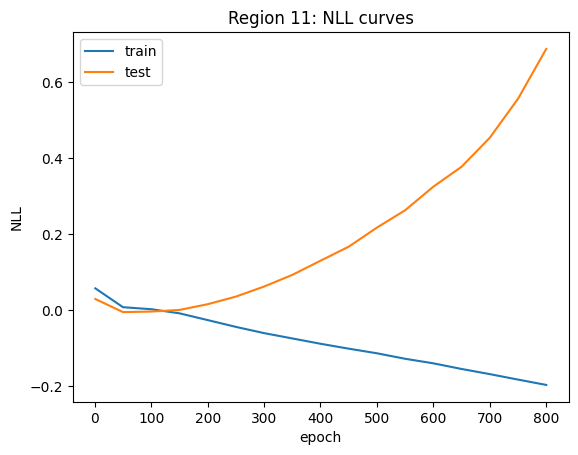

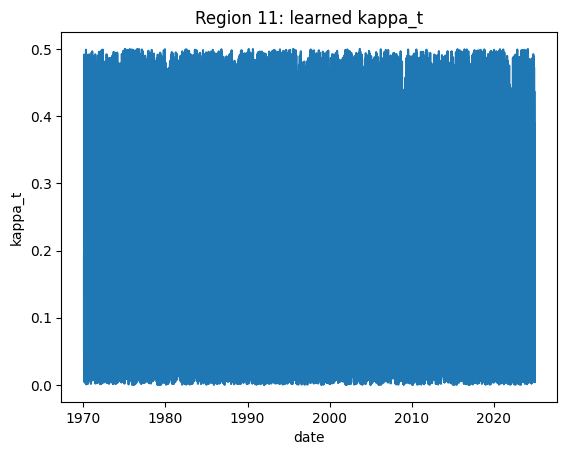

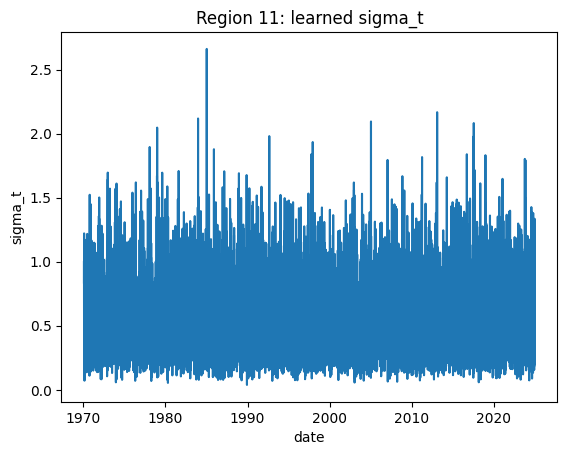

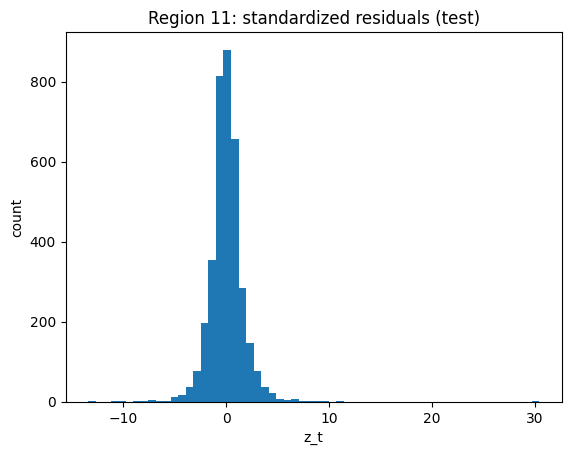

z mean: 0.031002793461084366 z std: 1.6597224473953247
saved model: per_region_models/calibnet_region_11.pt


In [ ]:
art = region_artifacts[REGION_TO_PLOT]
dfr = art["df"]

dates_k = dfr.loc[art["idx_t"], "date"].values

plt.figure()
plt.plot(art["epochs_logged"], art["train_curve"], label="train")
plt.plot(art["epochs_logged"], art["test_curve"], label="test")
plt.title(f"Region {REGION_TO_PLOT}: NLL curves")
plt.xlabel("epoch")
plt.ylabel("NLL")
plt.legend()
plt.show()

plt.figure()
plt.plot(dates_k, art["kappa_all"])
plt.title(f"Region {REGION_TO_PLOT}: learned kappa_t")
plt.xlabel("date")
plt.ylabel("kappa_t")
plt.show()

plt.figure()
plt.plot(dates_k, art["sigma_all"])
plt.title(f"Region {REGION_TO_PLOT}: learned sigma_t")
plt.xlabel("date")
plt.ylabel("sigma_t")
plt.show()

plt.figure()
plt.hist(art["z_test"], bins=60)
plt.title(f"Region {REGION_TO_PLOT}: standardized residuals (test)")
plt.xlabel("z_t")
plt.ylabel("count")
plt.show()

print("z mean:", float(np.mean(art["z_test"])), "z std:", float(np.std(art["z_test"])))
print("saved model:", art["save_path"])


## 6) Optional: simulate temperatures for that region and compute HDD example

This uses the trained NN to produce $(\kappa_t,\sigma_t)$ step-by-step. Residuals are simulated in **standardized units** and then mapped back to original units.

In [ ]:
@dataclass
class SimConfig:
    horizon_days: int = 90
    n_paths: int = 2000
    base_temp: float = 18.0
    tick_value: float = 1.0
    dt: float = 1.0

def simulate_region(art, model, start_index: int, sim: SimConfig):
    dfr = art["df"].copy()
    beta = art["beta"]
    x_mean, x_std = float(np.mean(art["x"])), float(np.std(art["x"]) + 1e-8)

    # Start from observed day
    x0 = float(art["x"][start_index])
    x0z = (x0 - x_mean) / x_std

    start_date = dfr.loc[start_index, "date"]
    dates = pd.date_range(start_date, periods=sim.horizon_days+1, freq="D")

    # seasonal mean future
    X_design = design_matrix_seasonality(pd.Series(dates), K=K_HARMONICS, include_trend=True)
    s_future = X_design @ beta

    # history window from standardized residuals
    xz_series = ((art["x"] - x_mean) / x_std).astype(np.float32)
    hist = xz_series[max(0, start_index-WINDOW):start_index]
    if len(hist) < WINDOW:
        hist = np.pad(hist, (WINDOW-len(hist), 0), mode="edge")

    X_paths_z = np.zeros((sim.n_paths, sim.horizon_days+1), dtype=np.float32)
    T_paths = np.zeros((sim.n_paths, sim.horizon_days+1), dtype=np.float32)

    X_paths_z[:, 0] = x0z
    T_paths[:, 0] = s_future[0] + x0

    for t in range(sim.horizon_days):
        feat = doy_features(pd.Series([dates[t]]), harmonics=DOY_HARMONICS).astype(np.float32).reshape(-1)
        inp = np.concatenate([hist[-WINDOW:], feat], axis=0)[None, :]
        inp_t = torch.tensor(inp, dtype=torch.float32, device=device)

        with torch.no_grad():
            kappa_t, sigma_t = model(inp_t)
        kappa_t = float(kappa_t.item())
        sigma_t = float(sigma_t.item())

        eps = np.random.randn(sim.n_paths).astype(np.float32)
        x_next_z = X_paths_z[:, t] - kappa_t * X_paths_z[:, t] * sim.dt + sigma_t * np.sqrt(sim.dt) * eps

        X_paths_z[:, t+1] = x_next_z

        # map back to original residual + temp
        x_next = x_next_z * x_std + x_mean
        T_paths[:, t+1] = s_future[t+1] + x_next

        hist = np.append(hist, x_next_z.mean())

    return T_paths

SIM_REGION = REGION_TO_PLOT
sim_cfg = SimConfig(horizon_days=90, n_paths=3000, base_temp=18.0, tick_value=1.0)

art = region_artifacts[SIM_REGION]
model = models[SIM_REGION]
# start from last 20% of sample
start_index = int(len(art["df"]) * 0.85)

T_paths = simulate_region(art, model, start_index=start_index, sim=sim_cfg)
T_paths.shape


(3000, 91)

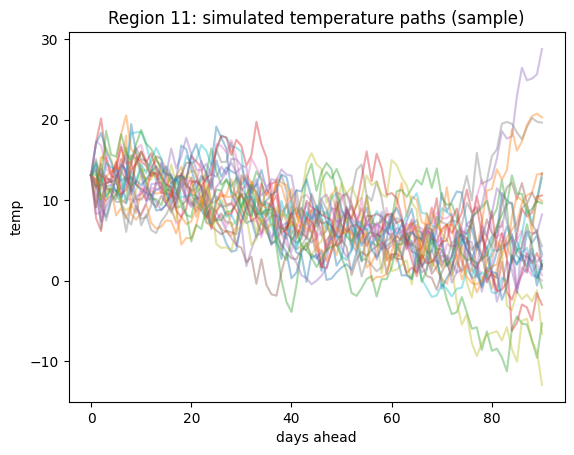

Expected HDD: 980.3499755859375
Std HDD: 120.55706787109375
Expected payoff: 980.3499755859375


In [ ]:
plt.figure()
for i in range(25):
    plt.plot(T_paths[i], alpha=0.4)
plt.title(f"Region {SIM_REGION}: simulated temperature paths (sample)")
plt.xlabel("days ahead")
plt.ylabel("temp")
plt.show()

K_base = sim_cfg.base_temp
hdd = np.maximum(0.0, K_base - T_paths[:, 1:]).sum(axis=1)
payoff = sim_cfg.tick_value * hdd
print("Expected HDD:", float(hdd.mean()))
print("Std HDD:", float(hdd.std()))
print("Expected payoff:", float(payoff.mean()))


# MODEL 1B: Per-region OU + NN with explicit seasonal volatility head
#
#### This section keeps the original per-region OU+NN results unchanged,
#### and trains a second model where:
##
####   kappa_t = f_kappa(residual history)
####   sigma_t = f_sigma(residual history, seasonal DOY features)
##
#### The goal is to improve volatility calibration, especially z_std.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

class CalibNetSeasonalSigma(nn.Module):
    def __init__(self, window: int, doy_dim: int, hidden: int = 64, kappa_max: float = 0.5):
        super().__init__()
        self.window = window
        self.doy_dim = doy_dim
        self.kappa_max = kappa_max
        self.softplus = nn.Softplus()

        # kappa branch: mainly driven by residual history
        self.kappa_net = nn.Sequential(
            nn.Linear(window, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1),
        )

        # sigma branch: residual history + seasonal features
        self.sigma_net = nn.Sequential(
            nn.Linear(window + doy_dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        """
        x shape: (batch, window + doy_dim)
        first 'window' columns: residual history
        last 'doy_dim' columns: seasonal features
        """
        x_hist = x[:, :self.window]
        x_doy = x[:, self.window:]

        raw_kappa = self.kappa_net(x_hist).squeeze(-1)
        raw_sigma = self.sigma_net(torch.cat([x_hist, x_doy], dim=1)).squeeze(-1)

        kappa = self.kappa_max * torch.sigmoid(raw_kappa) + 1e-6
        sigma = self.softplus(raw_sigma) + 1e-6
        return kappa, sigma


def ou_nll_euler_safe(x_t, x_tp1, kappa, sigma, dt: float = 1.0):
    mean = x_t - kappa * x_t * dt
    var = (sigma ** 2) * dt
    var = torch.clamp(var, min=1e-6)
    resid2 = (x_tp1 - mean) ** 2
    resid2 = torch.clamp(resid2, max=1e8)
    return 0.5 * (torch.log(var) + resid2 / var).mean()

def doy_features_seasonal_sigma(dates: pd.Series, harmonics: int = 5) -> np.ndarray:
    """
    Stronger seasonal encoding for volatility.
    Returns shape (N, 2*harmonics)
    """
    doy = dates.dt.dayofyear.values.astype(float)
    feats = []
    for k in range(1, harmonics + 1):
        feats.append(np.sin(2 * np.pi * k * doy / 365.0))
        feats.append(np.cos(2 * np.pi * k * doy / 365.0))
    return np.column_stack(feats)

# --- Hyperparameters for the seasonal-sigma remake ---
K_HARMONICS_SS = 3          # seasonal mean harmonics
DOY_HARMONICS_SS = 5        # stronger seasonal features for sigma
WINDOW_SS = 30
DT_SS = 1.0
EPOCHS_SS = 800
LR_SS = 1e-3
HIDDEN_SS = 64
KAPPA_MAX_SS = 0.5

OUT_DIR_SS = "per_region_models_seasonal_sigma"
os.makedirs(OUT_DIR_SS, exist_ok=True)

results_seasonal_sigma = []
models_seasonal_sigma = {}
region_artifacts_seasonal_sigma = {}

regions_ss = sorted(df_raw["region_code"].unique().tolist())

for r in regions_ss:
    dfr = df_raw[df_raw["region_code"] == r].sort_values("date").reset_index(drop=True)

    # Ensure one value per date per region
    dfr = dfr.groupby("date", as_index=False)["temp"].mean()

    if len(dfr) < (WINDOW_SS + 60):
        results_seasonal_sigma.append({
            "region": r,
            "status": "skipped (too short)",
            "n_days": len(dfr)
        })
        continue

    # 1) Fit seasonal mean
    s_hat, beta = fit_seasonal_mean(dfr["date"], dfr["temp"].values, K=K_HARMONICS_SS)

    # 2) Residuals
    x = (dfr["temp"].values - s_hat).astype(np.float32)

    # 3) Standardize residuals for stable training
    x_mean = float(np.mean(x))
    x_std = float(np.std(x) + 1e-8)
    xz = (x - x_mean) / x_std

    # 4) Features
    doy_feat_ss = doy_features_seasonal_sigma(dfr["date"], harmonics=DOY_HARMONICS_SS)

    X_in_ss, x_t_ss, x_tp1_ss, idx_t_ss = make_windows(
        xz,
        doy_feat_ss,
        window=WINDOW_SS
    )

    N = X_in_ss.shape[0]
    split = int(0.8 * N)

    X_train_ss = torch.tensor(X_in_ss[:split], dtype=torch.float32, device=device)
    x_t_train_ss = torch.tensor(x_t_ss[:split], dtype=torch.float32, device=device)
    x_tp1_train_ss = torch.tensor(x_tp1_ss[:split], dtype=torch.float32, device=device)

    X_test_ss = torch.tensor(X_in_ss[split:], dtype=torch.float32, device=device)
    x_t_test_ss = torch.tensor(x_t_ss[split:], dtype=torch.float32, device=device)
    x_tp1_test_ss = torch.tensor(x_tp1_ss[split:], dtype=torch.float32, device=device)

    # 5) Model
    model_ss = CalibNetSeasonalSigma(
        window=WINDOW_SS,
        doy_dim=2 * DOY_HARMONICS_SS,
        hidden=HIDDEN_SS,
        kappa_max=KAPPA_MAX_SS
    ).to(device)

    opt_ss = torch.optim.Adam(model_ss.parameters(), lr=LR_SS)

    train_curve_ss, test_curve_ss, epochs_logged_ss = [], [], []

    # 6) Train
    for epoch in range(1, EPOCHS_SS + 1):
        model_ss.train()
        kappa_ss, sigma_ss = model_ss(X_train_ss)
        loss_ss = ou_nll_euler_safe(
            x_t_train_ss, x_tp1_train_ss, kappa_ss, sigma_ss, dt=DT_SS
        )

        opt_ss.zero_grad()
        loss_ss.backward()
        torch.nn.utils.clip_grad_norm_(model_ss.parameters(), 1.0)
        opt_ss.step()

        if epoch % 50 == 0 or epoch == 1:
            model_ss.eval()
            with torch.no_grad():
                k_te_ss, s_te_ss = model_ss(X_test_ss)
                loss_te_ss = ou_nll_euler_safe(
                    x_t_test_ss, x_tp1_test_ss, k_te_ss, s_te_ss, dt=DT_SS
                )

            train_curve_ss.append(float(loss_ss.item()))
            test_curve_ss.append(float(loss_te_ss.item()))
            epochs_logged_ss.append(epoch)

    # 7) Evaluate on all windows
    model_ss.eval()
    with torch.no_grad():
        k_all_ss, s_all_ss = model_ss(torch.tensor(X_in_ss, dtype=torch.float32, device=device))

    k_all_ss = k_all_ss.detach().cpu().numpy()
    s_all_ss = s_all_ss.detach().cpu().numpy()

    # 8) Standardized residuals on test
    with torch.no_grad():
        k_te_ss, s_te_ss = model_ss(X_test_ss)
        mean_te_ss = x_t_test_ss - k_te_ss * x_t_test_ss * DT_SS
        z_te_ss = (x_tp1_test_ss - mean_te_ss) / (s_te_ss * np.sqrt(DT_SS))

    z_te_ss = z_te_ss.detach().cpu().numpy()

    # 9) Save model
    save_path_ss = os.path.join(OUT_DIR_SS, f"calibnet_seasonal_sigma_region_{r}.pt")
    torch.save({
        "state_dict": model_ss.state_dict(),
        "window": WINDOW_SS,
        "doy_harmonics": DOY_HARMONICS_SS,
        "k_harmonics": K_HARMONICS_SS,
        "beta": beta,
        "x_mean": x_mean,
        "x_std": x_std,
        "kappa_max": KAPPA_MAX_SS,
        "hidden": HIDDEN_SS,
    }, save_path_ss)

    models_seasonal_sigma[r] = model_ss
    region_artifacts_seasonal_sigma[r] = {
        "df": dfr,
        "beta": beta,
        "s_hat": s_hat,
        "x": x,
        "xz": xz,
        "idx_t": idx_t_ss,
        "kappa_all": k_all_ss,
        "sigma_all": s_all_ss,
        "train_curve": train_curve_ss,
        "test_curve": test_curve_ss,
        "epochs_logged": epochs_logged_ss,
        "z_test": z_te_ss,
        "save_path": save_path_ss,
    }

    results_seasonal_sigma.append({
        "region": r,
        "status": "ok",
        "n_days": len(dfr),
        "train_nll_last": train_curve_ss[-1] if len(train_curve_ss) else np.nan,
        "test_nll_last": test_curve_ss[-1] if len(test_curve_ss) else np.nan,
        "z_mean": float(np.mean(z_te_ss)),
        "z_std": float(np.std(z_te_ss)),
        "model_path": save_path_ss,
    })

summary_seasonal_sigma = pd.DataFrame(results_seasonal_sigma).sort_values(["status", "region"]).reset_index(drop=True)
summary_seasonal_sigma

# Compare old summary vs new seasonal-sigma summary
compare_cols_old = ["region", "train_nll_last", "test_nll_last", "z_mean", "z_std"]
compare_cols_new = ["region", "train_nll_last", "test_nll_last", "z_mean", "z_std"]

old_cmp = summary[compare_cols_old].copy().rename(columns={
    "train_nll_last": "train_nll_old",
    "test_nll_last": "test_nll_old",
    "z_mean": "z_mean_old",
    "z_std": "z_std_old",
})

new_cmp = summary_seasonal_sigma[compare_cols_new].copy().rename(columns={
    "train_nll_last": "train_nll_new",
    "test_nll_last": "test_nll_new",
    "z_mean": "z_mean_new",
    "z_std": "z_std_new",
})

comparison = old_cmp.merge(new_cmp, on="region", how="inner")

comparison["delta_test_nll"] = comparison["test_nll_new"] - comparison["test_nll_old"]
comparison["delta_z_std"] = comparison["z_std_new"] - comparison["z_std_old"]

comparison = comparison.sort_values("region").reset_index(drop=True)
comparison

The introduction of an explicit seasonal volatility head did not improve model performance. Test likelihood increased and standardized residual variance moved further from the theoretical value of one, suggesting that volatility dynamics depend more strongly on short-term residual history than purely on seasonal factors.

In [19]:
# ============================================================
# MODEL B / C PREP
# Build region-specific volatility correction factors
# from the ORIGINAL model diagnostics
# ============================================================

# Uses:
#   summary
#   region_artifacts
#   models
# from your original notebook

vol_correction = {}

for _, row in summary.iterrows():
    if row["status"] == "ok":
        r = int(row["region"])
        # Simple correction: empirical std of standardized residuals
        vol_correction[r] = float(row["z_std"])

vol_corr_df = pd.DataFrame({
    "region": list(vol_correction.keys()),
    "vol_multiplier": list(vol_correction.values())
}).sort_values("region").reset_index(drop=True)

vol_corr_df

,region,vol_multiplier
0,11,1.659722
1,24,1.542472
2,27,1.708630
3,28,1.552320
4,32,1.817543
5,44,1.399454
6,52,1.410453
7,53,1.455926


In [20]:
# ============================================================
# MODEL B
# Original model + region-specific volatility correction
# ============================================================

from dataclasses import dataclass
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

@dataclass
class SimConfigBC:
    horizon_days: int = 90
    n_paths: int = 3000
    base_temp: float = 18.0
    tick_value: float = 1.0
    dt: float = 1.0

def simulate_region_modelB(art, model, region_id: int, start_index: int, sim: SimConfigBC):
    """
    Simulate future temperatures using:
      ORIGINAL model
      + volatility correction sigma_t <- z_std(region) * sigma_t

    art  : region_artifacts[region_id]
    model: models[region_id]
    """
    dfr = art["df"].copy()
    beta = art["beta"]

    x_mean = float(np.mean(art["x"]))
    x_std = float(np.std(art["x"]) + 1e-8)

    # region-specific volatility correction
    vol_mult = float(vol_correction[region_id])

    # start from observed residual
    x0 = float(art["x"][start_index])
    x0z = (x0 - x_mean) / x_std

    start_date = dfr.loc[start_index, "date"]
    dates = pd.date_range(start_date, periods=sim.horizon_days + 1, freq="D")

    # future seasonal mean
    X_design = design_matrix_seasonality(pd.Series(dates), K=K_HARMONICS, include_trend=True)
    s_future = X_design @ beta

    # standardized residual history
    xz_series = ((art["x"] - x_mean) / x_std).astype(np.float32)
    hist = xz_series[max(0, start_index - WINDOW):start_index]
    if len(hist) < WINDOW:
        hist = np.pad(hist, (WINDOW - len(hist), 0), mode="edge")

    X_paths_z = np.zeros((sim.n_paths, sim.horizon_days + 1), dtype=np.float32)
    T_paths = np.zeros((sim.n_paths, sim.horizon_days + 1), dtype=np.float32)

    X_paths_z[:, 0] = x0z
    T_paths[:, 0] = s_future[0] + x0

    for t in range(sim.horizon_days):
        feat = doy_features(pd.Series([dates[t]]), harmonics=DOY_HARMONICS).astype(np.float32).reshape(-1)
        inp = np.concatenate([hist[-WINDOW:], feat], axis=0)[None, :]
        inp_t = torch.tensor(inp, dtype=torch.float32, device=device)

        with torch.no_grad():
            kappa_t, sigma_t = model(inp_t)

        kappa_t = float(kappa_t.item())
        sigma_t = float(sigma_t.item())

        # MODEL B correction
        sigma_t_corr = vol_mult * sigma_t

        eps = np.random.randn(sim.n_paths).astype(np.float32)
        x_next_z = X_paths_z[:, t] - kappa_t * X_paths_z[:, t] * sim.dt + sigma_t_corr * np.sqrt(sim.dt) * eps

        X_paths_z[:, t + 1] = x_next_z

        # back to original units
        x_next = x_next_z * x_std + x_mean
        T_paths[:, t + 1] = s_future[t + 1] + x_next

        # update history with mean path residual
        hist = np.append(hist, x_next_z.mean())

    return T_paths

In [21]:
# ============================================================
# MODEL C
# Original model + volatility correction + Student-t shocks
# ============================================================

def simulate_region_modelC(art, model, region_id: int, start_index: int, sim: SimConfigBC, df_t: int = 7):
    """
    Simulate future temperatures using:
      ORIGINAL model
      + volatility correction
      + Student-t shocks

    df_t = degrees of freedom of Student-t
    """
    dfr = art["df"].copy()
    beta = art["beta"]

    x_mean = float(np.mean(art["x"]))
    x_std = float(np.std(art["x"]) + 1e-8)

    vol_mult = float(vol_correction[region_id])

    x0 = float(art["x"][start_index])
    x0z = (x0 - x_mean) / x_std

    start_date = dfr.loc[start_index, "date"]
    dates = pd.date_range(start_date, periods=sim.horizon_days + 1, freq="D")

    X_design = design_matrix_seasonality(pd.Series(dates), K=K_HARMONICS, include_trend=True)
    s_future = X_design @ beta

    xz_series = ((art["x"] - x_mean) / x_std).astype(np.float32)
    hist = xz_series[max(0, start_index - WINDOW):start_index]
    if len(hist) < WINDOW:
        hist = np.pad(hist, (WINDOW - len(hist), 0), mode="edge")

    X_paths_z = np.zeros((sim.n_paths, sim.horizon_days + 1), dtype=np.float32)
    T_paths = np.zeros((sim.n_paths, sim.horizon_days + 1), dtype=np.float32)

    X_paths_z[:, 0] = x0z
    T_paths[:, 0] = s_future[0] + x0

    # scale Student-t so variance is 1 when df_t > 2
    t_scale = np.sqrt((df_t - 2) / df_t)

    for t in range(sim.horizon_days):
        feat = doy_features(pd.Series([dates[t]]), harmonics=DOY_HARMONICS).astype(np.float32).reshape(-1)
        inp = np.concatenate([hist[-WINDOW:], feat], axis=0)[None, :]
        inp_t = torch.tensor(inp, dtype=torch.float32, device=device)

        with torch.no_grad():
            kappa_t, sigma_t = model(inp_t)

        kappa_t = float(kappa_t.item())
        sigma_t = float(sigma_t.item())

        sigma_t_corr = vol_mult * sigma_t

        # Student-t shocks with unit variance
        eps = (np.random.standard_t(df=df_t, size=sim.n_paths) * t_scale).astype(np.float32)

        x_next_z = X_paths_z[:, t] - kappa_t * X_paths_z[:, t] * sim.dt + sigma_t_corr * np.sqrt(sim.dt) * eps

        X_paths_z[:, t + 1] = x_next_z

        x_next = x_next_z * x_std + x_mean
        T_paths[:, t + 1] = s_future[t + 1] + x_next

        hist = np.append(hist, x_next_z.mean())

    return T_paths

In [ ]:
# ============================================================
# COMPARE MODEL A vs B vs C FOR ONE REGION
# ============================================================

SIM_REGION = 11   # change as needed
sim_cfg_bc = SimConfigBC(horizon_days=90, n_paths=3000, base_temp=18.0, tick_value=1.0, dt=1.0)

art = region_artifacts[SIM_REGION]
model = models[SIM_REGION]
start_index = int(len(art["df"]) * 0.85)

# Model A = original simulation function from your notebook
T_paths_A = simulate_region(art, model, start_index=start_index, sim=sim_cfg_bc)

# Model B = corrected volatility
T_paths_B = simulate_region_modelB(art, model, region_id=SIM_REGION, start_index=start_index, sim=sim_cfg_bc)

# Model C = corrected volatility + Student-t shocks
T_paths_C = simulate_region_modelC(art, model, region_id=SIM_REGION, start_index=start_index, sim=sim_cfg_bc, df_t=7)

print(T_paths_A.shape, T_paths_B.shape, T_paths_C.shape)

(3000, 91) (3000, 91) (3000, 91)


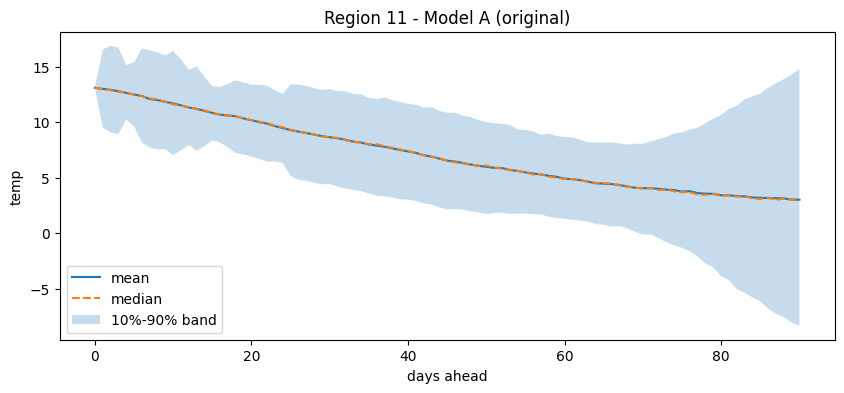

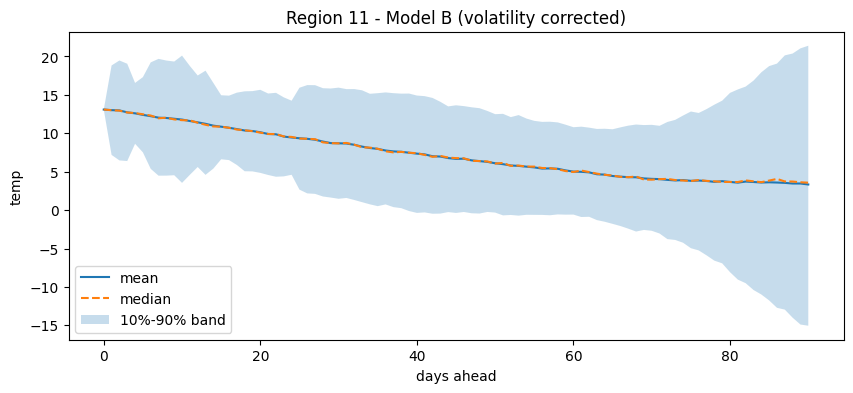

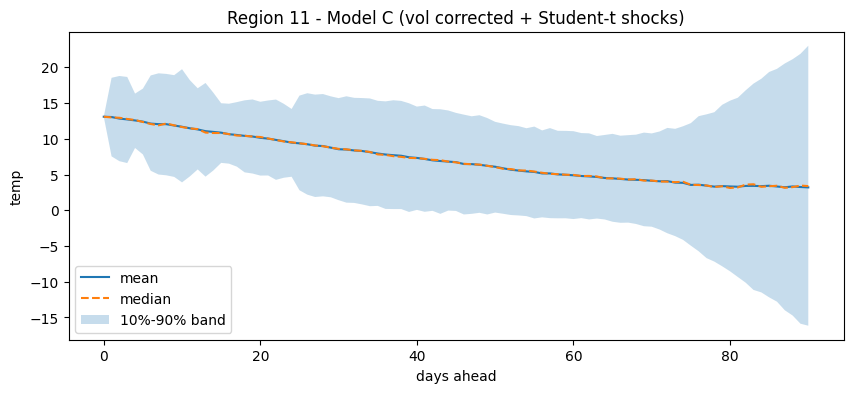

In [ ]:
# ============================================================
# PLOT FAN CHARTS FOR MODEL A / B / C
# ============================================================

def plot_fan_chart(T_paths, title):
    mean = T_paths.mean(axis=0)
    q10 = np.quantile(T_paths, 0.10, axis=0)
    q50 = np.quantile(T_paths, 0.50, axis=0)
    q90 = np.quantile(T_paths, 0.90, axis=0)

    plt.figure(figsize=(10, 4))
    plt.plot(mean, label="mean")
    plt.plot(q50, label="median", linestyle="--")
    plt.fill_between(np.arange(len(mean)), q10, q90, alpha=0.25, label="10%-90% band")
    plt.title(title)
    plt.xlabel("days ahead")
    plt.ylabel("temp")
    plt.legend()
    plt.show()

plot_fan_chart(T_paths_A, f"Region {SIM_REGION} - Model A (original)")
plot_fan_chart(T_paths_B, f"Region {SIM_REGION} - Model B (volatility corrected)")
plot_fan_chart(T_paths_C, f"Region {SIM_REGION} - Model C (vol corrected + Student-t shocks)")

In [24]:
# ============================================================
# HDD / PAYOFF COMPARISON
# ============================================================

def hdd_stats(T_paths, base_temp=18.0, tick_value=1.0):
    hdd = np.maximum(0.0, base_temp - T_paths[:, 1:]).sum(axis=1)
    payoff = tick_value * hdd
    return {
        "expected_HDD": float(np.mean(hdd)),
        "std_HDD": float(np.std(hdd)),
        "q05_HDD": float(np.quantile(hdd, 0.05)),
        "q50_HDD": float(np.quantile(hdd, 0.50)),
        "q95_HDD": float(np.quantile(hdd, 0.95)),
        "expected_payoff": float(np.mean(payoff)),
        "std_payoff": float(np.std(payoff)),
    }

stats_A = hdd_stats(T_paths_A, base_temp=sim_cfg_bc.base_temp, tick_value=sim_cfg_bc.tick_value)
stats_B = hdd_stats(T_paths_B, base_temp=sim_cfg_bc.base_temp, tick_value=sim_cfg_bc.tick_value)
stats_C = hdd_stats(T_paths_C, base_temp=sim_cfg_bc.base_temp, tick_value=sim_cfg_bc.tick_value)

comparison_hdd = pd.DataFrame([
    {"model": "A_original", **stats_A},
    {"model": "B_vol_corrected", **stats_B},
    {"model": "C_vol_corrected_t", **stats_C},
])

comparison_hdd

,model,expected_HDD,std_HDD,q05_HDD,q50_HDD,q95_HDD,expected_payoff,std_payoff
0,A_original,983.584656,119.952423,793.003174,982.975708,1185.491089,983.584656,119.952423
1,B_vol_corrected,989.996826,186.133560,698.181274,982.887451,1316.444702,989.996826,186.133560
2,C_vol_corrected_t,999.944641,188.867920,709.086975,986.284546,1329.749390,999.944641,188.867920


In [ ]:
# ============================================================
# ALL-REGION COMPARISON TABLE FOR A / B / C
# ============================================================

all_region_hdd = []

for r in sorted([rr for rr in region_artifacts.keys() if rr in models]):
    art = region_artifacts[r]
    model = models[r]
    start_index = int(len(art["df"]) * 0.85)

    T_A = simulate_region(art, model, start_index=start_index, sim=sim_cfg_bc)
    T_B = simulate_region_modelB(art, model, region_id=r, start_index=start_index, sim=sim_cfg_bc)
    T_C = simulate_region_modelC(art, model, region_id=r, start_index=start_index, sim=sim_cfg_bc, df_t=7)

    sA = hdd_stats(T_A, base_temp=sim_cfg_bc.base_temp, tick_value=sim_cfg_bc.tick_value)
    sB = hdd_stats(T_B, base_temp=sim_cfg_bc.base_temp, tick_value=sim_cfg_bc.tick_value)
    sC = hdd_stats(T_C, base_temp=sim_cfg_bc.base_temp, tick_value=sim_cfg_bc.tick_value)

    all_region_hdd.append({
        "region": r,
        "A_expected_HDD": sA["expected_HDD"],
        "B_expected_HDD": sB["expected_HDD"],
        "C_expected_HDD": sC["expected_HDD"],
        "A_std_HDD": sA["std_HDD"],
        "B_std_HDD": sB["std_HDD"],
        "C_std_HDD": sC["std_HDD"],
        "A_expected_payoff": sA["expected_payoff"],
        "B_expected_payoff": sB["expected_payoff"],
        "C_expected_payoff": sC["expected_payoff"],
    })

all_region_hdd_df = pd.DataFrame(all_region_hdd).sort_values("region").reset_index(drop=True)
all_region_hdd_df

,region,A_expected_HDD,B_expected_HDD,C_expected_HDD,A_std_HDD,B_std_HDD,C_std_HDD,A_expected_payoff,B_expected_payoff,C_expected_payoff
0,11,980.512268,992.675110,992.165344,119.019356,191.681229,187.767487,980.512268,992.675110,992.165344
1,24,978.450073,988.041565,988.733826,98.352417,145.584885,145.925293,978.450073,988.041565,988.733826
2,27,1123.476440,1131.091797,1136.530640,81.931274,132.174225,131.788345,1123.476440,1131.091797,1136.530640
3,28,827.476318,834.987000,827.073669,66.780495,100.868187,103.005768,827.476318,834.987000,827.073669
4,32,204.984421,292.490051,288.477631,84.889763,146.473175,150.361099,204.984421,292.490051,288.477631
5,44,1142.466675,1149.277710,1150.280518,380.265076,461.217773,460.361816,1142.466675,1149.277710,1150.280518
6,52,824.592346,831.839478,830.260986,105.310150,149.677887,146.214035,824.592346,831.839478,830.260986
7,53,763.396362,773.311890,766.512390,108.358994,151.309357,147.373444,763.396362,773.311890,766.512390


In [ ]:
# ============================================================
# ALL-MODEL DIAGNOSTICS COMPARISON: A vs B vs C
# ============================================================

import numpy as np
import pandas as pd
import torch

def compute_skewness(x):
    x = np.asarray(x)
    m = np.mean(x)
    s = np.std(x) + 1e-12
    return np.mean(((x - m) / s) ** 3)

def compute_kurtosis(x):
    x = np.asarray(x)
    m = np.mean(x)
    s = np.std(x) + 1e-12
    return np.mean(((x - m) / s) ** 4)  # normal = 3

def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    err = y_true - y_pred
    mae = np.mean(np.abs(err))
    rmse = np.sqrt(np.mean(err ** 2))

    ss_res = np.sum(err ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2) + 1e-12
    r2 = 1.0 - ss_res / ss_tot

    corr = np.corrcoef(y_true, y_pred)[0, 1] if len(y_true) > 1 else np.nan

    return {
        "mae": float(mae),
        "rmse": float(rmse),
        "r2": float(r2),
        "corr": float(corr),
    }

def interval_metrics(y_true, mean_pred, sigma_pred, alpha=0.10):
    # central 90% interval under Gaussian assumption
    zcrit = 1.6448536269514722
    lower = mean_pred - zcrit * sigma_pred
    upper = mean_pred + zcrit * sigma_pred

    covered = ((y_true >= lower) & (y_true <= upper)).astype(float)
    picp = np.mean(covered)
    mpiw = np.mean(upper - lower)

    return {
        "picp_90": float(picp),
        "mpiw_90": float(mpiw),
    }

def diagnostics_from_predictions(y_true, y_pred, sigma_pred):
    """
    y_true, y_pred, sigma_pred in ORIGINAL units
    """
    reg = regression_metrics(y_true, y_pred)
    ivl = interval_metrics(y_true, y_pred, sigma_pred, alpha=0.10)

    z = (y_true - y_pred) / (sigma_pred + 1e-12)

    return {
        "mae": reg["mae"],
        "rmse": reg["rmse"],
        "r2": reg["r2"],
        "corr": reg["corr"],
        "picp_90": ivl["picp_90"],
        "mpiw_90": ivl["mpiw_90"],
        "z_mean": float(np.mean(z)),
        "z_std": float(np.std(z)),
        "z_skew": float(compute_skewness(z)),
        "z_kurtosis": float(compute_kurtosis(z)),
    }

def diagnostics_model_A(art, model, dfr, x_mean, x_std):
    """
    Original model:
      mean = x_t - kappa_t x_t
      sigma = sigma_t
    """
    x = np.asarray(art["x"], dtype=np.float32)
    xz = ((x - x_mean) / x_std).astype(np.float32)

    doy_feat = doy_features(dfr["date"], harmonics=DOY_HARMONICS)
    X_in, x_t, x_tp1, idx_t = make_windows(xz, doy_feat, window=WINDOW)

    N = X_in.shape[0]
    split = int(0.8 * N)

    X_test = torch.tensor(X_in[split:], dtype=torch.float32, device=device)
    x_t_test = x_t[split:]
    x_tp1_test = x_tp1[split:]

    model.eval()
    with torch.no_grad():
        kappa_te, sigma_te = model(X_test)

    kappa_te = kappa_te.detach().cpu().numpy()
    sigma_te = sigma_te.detach().cpu().numpy()

    mean_pred_z = x_t_test - kappa_te * x_t_test * DT

    y_true = x_tp1_test * x_std + x_mean
    y_pred = mean_pred_z * x_std + x_mean
    sigma_pred = sigma_te * x_std

    return diagnostics_from_predictions(y_true, y_pred, sigma_pred)

def diagnostics_model_B(art, model, dfr, x_mean, x_std, region_id):
    """
    Model B:
      original mean
      sigma = z_std(region) * sigma_t
    """
    x = np.asarray(art["x"], dtype=np.float32)
    xz = ((x - x_mean) / x_std).astype(np.float32)

    doy_feat = doy_features(dfr["date"], harmonics=DOY_HARMONICS)
    X_in, x_t, x_tp1, idx_t = make_windows(xz, doy_feat, window=WINDOW)

    N = X_in.shape[0]
    split = int(0.8 * N)

    X_test = torch.tensor(X_in[split:], dtype=torch.float32, device=device)
    x_t_test = x_t[split:]
    x_tp1_test = x_tp1[split:]

    model.eval()
    with torch.no_grad():
        kappa_te, sigma_te = model(X_test)

    kappa_te = kappa_te.detach().cpu().numpy()
    sigma_te = sigma_te.detach().cpu().numpy()

    vol_mult = float(vol_correction[region_id])

    mean_pred_z = x_t_test - kappa_te * x_t_test * DT

    y_true = x_tp1_test * x_std + x_mean
    y_pred = mean_pred_z * x_std + x_mean
    sigma_pred = (vol_mult * sigma_te) * x_std

    return diagnostics_from_predictions(y_true, y_pred, sigma_pred)

def diagnostics_model_C(art, model, dfr, x_mean, x_std, region_id, df_t=7):
    """
    Model C:
      original mean
      sigma = z_std(region) * sigma_t
      heavy-tail adjustment for Student-t shocks

    For Student-t with variance 1, standardized residual kurtosis increases,
    but for interval comparison we approximate effective predictive spread by
    the same sigma scale. This keeps comparison simple and fair at one-step level.
    """
    x = np.asarray(art["x"], dtype=np.float32)
    xz = ((x - x_mean) / x_std).astype(np.float32)

    doy_feat = doy_features(dfr["date"], harmonics=DOY_HARMONICS)
    X_in, x_t, x_tp1, idx_t = make_windows(xz, doy_feat, window=WINDOW)

    N = X_in.shape[0]
    split = int(0.8 * N)

    X_test = torch.tensor(X_in[split:], dtype=torch.float32, device=device)
    x_t_test = x_t[split:]
    x_tp1_test = x_tp1[split:]

    model.eval()
    with torch.no_grad():
        kappa_te, sigma_te = model(X_test)

    kappa_te = kappa_te.detach().cpu().numpy()
    sigma_te = sigma_te.detach().cpu().numpy()

    vol_mult = float(vol_correction[region_id])

    mean_pred_z = x_t_test - kappa_te * x_t_test * DT

    y_true = x_tp1_test * x_std + x_mean
    y_pred = mean_pred_z * x_std + x_mean

    # keep variance-matched sigma for one-step comparison
    sigma_pred = (vol_mult * sigma_te) * x_std

    out = diagnostics_from_predictions(y_true, y_pred, sigma_pred)
    out["student_t_df"] = df_t
    return out

# ------------------------------------------------------------
# RUN FOR ALL REGIONS AND ALL MODELS
# ------------------------------------------------------------

all_diag_rows = []

valid_regions = sorted([r for r in region_artifacts.keys() if r in models and r in vol_correction])

for r in valid_regions:
    art = region_artifacts[r]
    model = models[r]
    dfr = art["df"]

    x_mean = float(np.mean(art["x"]))
    x_std = float(np.std(art["x"]) + 1e-8)

    # Model A
    dA = diagnostics_model_A(art, model, dfr, x_mean, x_std)
    all_diag_rows.append({
        "region": r,
        "model": "A_original",
        **dA
    })

    # Model B
    dB = diagnostics_model_B(art, model, dfr, x_mean, x_std, region_id=r)
    all_diag_rows.append({
        "region": r,
        "model": "B_vol_corrected",
        **dB
    })

    # Model C
    dC = diagnostics_model_C(art, model, dfr, x_mean, x_std, region_id=r, df_t=7)
    all_diag_rows.append({
        "region": r,
        "model": "C_vol_corrected_t",
        **dC
    })

all_models_diagnostics = pd.DataFrame(all_diag_rows).sort_values(["region", "model"]).reset_index(drop=True)

# Optional helper columns
all_models_diagnostics["coverage_error_90"] = all_models_diagnostics["picp_90"] - 0.90
all_models_diagnostics["excess_kurtosis"] = all_models_diagnostics["z_kurtosis"] - 3.0

all_models_diagnostics

,region,model,mae,rmse,r2,corr,picp_90,mpiw_90,z_mean,z_std,z_skew,z_kurtosis,student_t_df,coverage_error_90,excess_kurtosis
0,11,A_original,1.621374,2.036533,0.588384,0.767843,0.797856,6.108014,0.030071,1.609131,1.540477,39.725597,NaN,-0.102144,36.725597
1,11,B_vol_corrected,1.621374,2.036533,0.588384,0.767843,0.932453,10.137608,0.018118,0.969518,1.540478,39.725594,NaN,0.032453,36.725594
2,11,C_vol_corrected_t,1.621374,2.036533,0.588384,0.767843,0.932453,10.137608,0.018118,0.969518,1.540478,39.725594,7.0,0.032453,36.725594
3,24,A_original,1.614572,2.023183,0.598421,0.773957,0.802841,6.081065,0.000650,1.500189,0.121343,8.452082,NaN,-0.097159,5.452082
4,24,B_vol_corrected,1.614572,2.023183,0.598421,0.773957,0.923230,9.379872,0.000421,0.972588,0.121343,8.452085,NaN,0.023230,5.452085
5,24,C_vol_corrected_t,1.614572,2.023183,0.598421,0.773957,0.923230,9.379872,0.000421,0.972588,0.121343,8.452085,7.0,0.023230,5.452085
6,27,A_original,1.568347,1.981144,0.639552,0.800235,0.805812,6.652715,0.014355,1.675896,0.038469,14.940606,NaN,-0.094188,11.940606
7,27,B_vol_corrected,1.568347,1.981144,0.639552,0.800235,0.924703,11.367030,0.008401,0.980842,0.038469,14.940606,NaN,0.024703,11.940606
8,27,C_vol_corrected_t,1.568347,1.981144,0.639552,0.800235,0.924703,11.367030,0.008401,0.980842,0.038469,14.940606,7.0,0.024703,11.940606
9,28,A_original,1.291836,1.656499,0.601310,0.775665,0.805833,4.885585,0.038128,1.507622,0.461988,8.678011,NaN,-0.094167,5.678011


# with estimated C based on B

In [27]:
# ============================================================
# ESTIMATE STUDENT-t DEGREES OF FREEDOM PER REGION
# from Model B standardized residuals
# ============================================================

import numpy as np
import pandas as pd
from scipy.stats import t

def estimate_student_df_from_residuals(z, df_grid=None):
    """
    Estimate Student-t df by MLE on standardized residuals z.
    Assumes z is approximately zero-mean and unit-scale after Model B correction.
    We fit only df over a grid for robustness.
    """
    z = np.asarray(z, dtype=float)
    z = z[np.isfinite(z)]

    # default search grid
    if df_grid is None:
        df_grid = np.concatenate([
            np.arange(3.0, 10.5, 0.5),
            np.arange(11.0, 31.0, 1.0),
            np.array([40.0, 60.0, 100.0])
        ])

    best_df = None
    best_nll = np.inf

    for df in df_grid:
        # scale Student-t to unit variance
        # if T ~ t_df, then T * sqrt((df-2)/df) has variance 1 for df>2
        scale_to_unit_var = np.sqrt((df - 2.0) / df)

        # scipy t.logpdf(x, df, loc=0, scale=s)
        # variance = df/(df-2) * scale^2
        ll = t.logpdf(z, df=df, loc=0.0, scale=scale_to_unit_var)
        nll = -np.sum(ll)

        if np.isfinite(nll) and nll < best_nll:
            best_nll = nll
            best_df = float(df)

    return best_df, best_nll


student_df_rows = []

for r in sorted([rr for rr in region_artifacts.keys() if rr in models and rr in vol_correction]):
    art = region_artifacts[r]
    model = models[r]
    dfr = art["df"]

    x = np.asarray(art["x"], dtype=np.float32)
    x_mean = float(np.mean(x))
    x_std = float(np.std(x) + 1e-8)
    xz = ((x - x_mean) / x_std).astype(np.float32)

    doy_feat = doy_features(dfr["date"], harmonics=DOY_HARMONICS)
    X_in, x_t, x_tp1, idx_t = make_windows(xz, doy_feat, window=WINDOW)

    # Use the SAME date-based split logic you now use
    window_dates = dfr.loc[idx_t, "date"].reset_index(drop=True)
    train_end_date = pd.Timestamp("2014-12-31")
    test_end_date = pd.Timestamp("2024-12-31")
    test_mask = (window_dates > train_end_date) & (window_dates <= test_end_date)

    X_test = torch.tensor(X_in[test_mask.values], dtype=torch.float32, device=device)
    x_t_test = x_t[test_mask.values]
    x_tp1_test = x_tp1[test_mask.values]

    model.eval()
    with torch.no_grad():
        kappa_te, sigma_te = model(X_test)

    kappa_te = kappa_te.detach().cpu().numpy()
    sigma_te = sigma_te.detach().cpu().numpy()

    # Model B residuals = volatility-corrected residuals
    vol_mult = float(vol_correction[r])
    sigma_te_corr = vol_mult * sigma_te

    mean_pred_z = x_t_test - kappa_te * x_t_test * DT
    z_B = (x_tp1_test - mean_pred_z) / (sigma_te_corr + 1e-12)

    best_df, best_nll = estimate_student_df_from_residuals(z_B)

    student_df_rows.append({
        "region": r,
        "student_t_df_hat": best_df,
        "student_t_nll": best_nll,
        "n_test_obs": int(len(z_B)),
        "z_mean_B": float(np.mean(z_B)),
        "z_std_B": float(np.std(z_B)),
        "z_kurtosis_B": float(np.mean(((z_B - np.mean(z_B)) / (np.std(z_B)+1e-12))**4)),
    })

student_df_df = pd.DataFrame(student_df_rows).sort_values("region").reset_index(drop=True)
student_df_df

,region,student_t_df_hat,student_t_nll,n_test_obs,z_mean_B,z_std_B,z_kurtosis_B
0,11,3.5,4678.756339,3652,0.018680,1.0,38.530201
1,24,4.0,4900.530765,3652,0.001037,1.0,8.269088
2,27,3.0,4546.127620,3651,-0.001985,1.0,14.075974
3,28,3.5,4849.052814,3652,0.026976,1.0,8.443081
4,32,3.0,4412.981413,3652,0.016554,1.0,19.932585
5,44,3.5,4788.742695,3652,0.033648,1.0,26.315569
6,52,4.0,4902.005398,3652,0.033268,1.0,7.835430
7,53,4.0,4901.241454,3652,-0.002144,1.0,7.435992


In [28]:
# ============================================================
# REGION-SPECIFIC STUDENT-t DF LOOKUP
# ============================================================

student_df_lookup = dict(
    zip(student_df_df["region"].astype(int), student_df_df["student_t_df_hat"].astype(float))
)

student_df_lookup

{11: 3.5, 24: 4.0, 27: 3.0, 28: 3.5, 32: 3.0, 44: 3.5, 52: 4.0, 53: 4.0}

In [29]:
# ============================================================
# MODEL C (UPDATED)
# Original model + volatility correction + region-specific Student-t df
# ============================================================

def simulate_region_modelC_regiondf(art, model, region_id: int, start_index: int, sim: SimConfigBC):
    """
    Simulate future temperatures using:
      ORIGINAL model
      + volatility correction
      + Student-t shocks with region-specific df
    """
    dfr = art["df"].copy()
    beta = art["beta"]

    x_mean = float(np.mean(art["x"]))
    x_std = float(np.std(art["x"]) + 1e-8)

    vol_mult = float(vol_correction[region_id])
    df_t = float(student_df_lookup[region_id])

    x0 = float(art["x"][start_index])
    x0z = (x0 - x_mean) / x_std

    start_date = dfr.loc[start_index, "date"]
    dates = pd.date_range(start_date, periods=sim.horizon_days + 1, freq="D")

    X_design = design_matrix_seasonality(pd.Series(dates), K=K_HARMONICS, include_trend=True)
    s_future = X_design @ beta

    xz_series = ((art["x"] - x_mean) / x_std).astype(np.float32)
    hist = xz_series[max(0, start_index - WINDOW):start_index]
    if len(hist) < WINDOW:
        hist = np.pad(hist, (WINDOW - len(hist), 0), mode="edge")

    X_paths_z = np.zeros((sim.n_paths, sim.horizon_days + 1), dtype=np.float32)
    T_paths = np.zeros((sim.n_paths, sim.horizon_days + 1), dtype=np.float32)

    X_paths_z[:, 0] = x0z
    T_paths[:, 0] = s_future[0] + x0

    # scale Student-t to unit variance
    t_scale = np.sqrt((df_t - 2.0) / df_t)

    for t_idx in range(sim.horizon_days):
        feat = doy_features(pd.Series([dates[t_idx]]), harmonics=DOY_HARMONICS).astype(np.float32).reshape(-1)
        inp = np.concatenate([hist[-WINDOW:], feat], axis=0)[None, :]
        inp_t = torch.tensor(inp, dtype=torch.float32, device=device)

        with torch.no_grad():
            kappa_t, sigma_t = model(inp_t)

        kappa_t = float(kappa_t.item())
        sigma_t = float(sigma_t.item())

        sigma_t_corr = vol_mult * sigma_t

        eps = (np.random.standard_t(df=df_t, size=sim.n_paths) * t_scale).astype(np.float32)

        x_next_z = (
            X_paths_z[:, t_idx]
            - kappa_t * X_paths_z[:, t_idx] * sim.dt
            + sigma_t_corr * np.sqrt(sim.dt) * eps
        )

        X_paths_z[:, t_idx + 1] = x_next_z

        x_next = x_next_z * x_std + x_mean
        T_paths[:, t_idx + 1] = s_future[t_idx + 1] + x_next

        hist = np.append(hist, x_next_z.mean())

    return T_paths

In [30]:
# ============================================================
# QUICK TEST: ONE REGION WITH REGION-SPECIFIC DF
# ============================================================

SIM_REGION = 11
sim_cfg_regiondf = SimConfigBC(
    horizon_days=90,
    n_paths=3000,
    base_temp=18.0,
    tick_value=1.0,
    dt=1.0
)

art = region_artifacts[SIM_REGION]
model = models[SIM_REGION]
start_index = int(len(art["df"]) * 0.85)

print("Region:", SIM_REGION)
print("Estimated Student-t df:", student_df_lookup[SIM_REGION])

T_paths_C_regiondf = simulate_region_modelC_regiondf(
    art, model, region_id=SIM_REGION, start_index=start_index, sim=sim_cfg_regiondf
)

T_paths_C_regiondf.shape

Region: 11
Estimated Student-t df: 3.5


(3000, 91)

In [31]:
# ============================================================
# COMPARE FIXED-DF C vs REGION-DF C
# ============================================================

# Old fixed-df version (if you still have the function)
T_paths_C_fixed = simulate_region_modelC(
    art, model, region_id=SIM_REGION, start_index=start_index, sim=sim_cfg_regiondf, df_t=7
)

# New region-specific df version
T_paths_C_regiondf = simulate_region_modelC_regiondf(
    art, model, region_id=SIM_REGION, start_index=start_index, sim=sim_cfg_regiondf
)

def hdd_stats_simple(T_paths, base_temp=18.0, tick_value=1.0):
    hdd = np.maximum(0.0, base_temp - T_paths[:, 1:]).sum(axis=1)
    payoff = tick_value * hdd
    return {
        "expected_HDD": float(np.mean(hdd)),
        "std_HDD": float(np.std(hdd)),
        "q95_HDD": float(np.quantile(hdd, 0.95)),
        "expected_payoff": float(np.mean(payoff)),
        "std_payoff": float(np.std(payoff)),
    }

compare_fixed_vs_regiondf = pd.DataFrame([
    {"model": "C_fixed_df7", **hdd_stats_simple(T_paths_C_fixed, base_temp=18.0, tick_value=1.0)},
    {"model": "C_region_df", **hdd_stats_simple(T_paths_C_regiondf, base_temp=18.0, tick_value=1.0)},
])

compare_fixed_vs_regiondf

,model,expected_HDD,std_HDD,q95_HDD,expected_payoff,std_payoff
0,C_fixed_df7,998.005188,185.983582,1313.011597,998.005188,185.983582
1,C_region_df,991.623413,183.941742,1303.513672,991.623413,183.941742


In [32]:
# ============================================================
# ALL-REGION SUMMARY FOR REGION-SPECIFIC STUDENT-t MODEL C
# ============================================================

all_region_regiondf = []

for r in sorted([rr for rr in region_artifacts.keys() if rr in models and rr in student_df_lookup]):
    art = region_artifacts[r]
    model = models[r]
    start_index = int(len(art["df"]) * 0.85)

    T_C_regiondf = simulate_region_modelC_regiondf(
        art, model, region_id=r, start_index=start_index, sim=sim_cfg_regiondf
    )

    hdd = np.maximum(0.0, sim_cfg_regiondf.base_temp - T_C_regiondf[:, 1:]).sum(axis=1)
    payoff = sim_cfg_regiondf.tick_value * hdd

    all_region_regiondf.append({
        "region": r,
        "student_t_df_hat": float(student_df_lookup[r]),
        "expected_HDD": float(np.mean(hdd)),
        "std_HDD": float(np.std(hdd)),
        "q95_HDD": float(np.quantile(hdd, 0.95)),
        "expected_payoff": float(np.mean(payoff)),
        "std_payoff": float(np.std(payoff)),
        "P(any day <= -10C)": float(np.mean(np.any(T_C_regiondf[:, 1:] <= -10.0, axis=1))),
        "P(any day >= 30C)": float(np.mean(np.any(T_C_regiondf[:, 1:] >= 30.0, axis=1))),
    })

all_region_regiondf_df = pd.DataFrame(all_region_regiondf).sort_values("region").reset_index(drop=True)
all_region_regiondf_df

,region,student_t_df_hat,expected_HDD,std_HDD,q95_HDD,expected_payoff,std_payoff,P(any day <= -10C),P(any day >= 30C)
0,11,3.5,987.570190,181.661621,1287.915405,987.570190,181.661621,0.325667,0.094000
1,24,4.0,988.349182,140.880096,1226.537598,988.349182,140.880096,0.324000,0.078000
2,27,3.0,1133.169189,127.127525,1343.456543,1133.169189,127.127525,0.488667,0.133000
3,28,3.5,831.610107,97.732994,997.788269,831.610107,97.732994,0.059333,0.024000
4,32,3.0,276.153656,137.136948,531.034119,276.153656,137.136948,0.050333,0.366000
5,44,3.5,1134.993774,441.931671,1917.059082,1134.993774,441.931671,0.418667,0.096667
6,52,4.0,827.070740,144.249527,1067.352905,827.070740,144.249527,0.098000,0.044667
7,53,4.0,769.263855,152.294556,1020.512024,769.263855,152.294556,0.088000,0.025667


In [ ]:
# ============================================================
# VISUAL COMPARISON OF MODELS A / B / C
# ============================================================

SIM_REGION = 11      # change as needed
DF_T = 7             # Student-t degrees of freedom for Model C
HORIZON = 90
N_PATHS = 4000
BASE_TEMP = 18.0
TICK_VALUE = 1.0

sim_cfg_vis = SimConfigBC(
    horizon_days=HORIZON,
    n_paths=N_PATHS,
    base_temp=BASE_TEMP,
    tick_value=TICK_VALUE,
    dt=1.0
)

art = region_artifacts[SIM_REGION]
model = models[SIM_REGION]
start_index = int(len(art["df"]) * 0.85)

# Simulate all three models
T_paths_A = simulate_region(art, model, start_index=start_index, sim=sim_cfg_vis)
T_paths_B = simulate_region_modelB(art, model, region_id=SIM_REGION, start_index=start_index, sim=sim_cfg_vis)
T_paths_C = simulate_region_modelC(art, model, region_id=SIM_REGION, start_index=start_index, sim=sim_cfg_vis, df_t=DF_T)

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def fan_stats(T_paths):
    return {
        "mean": np.mean(T_paths, axis=0),
        "q05": np.quantile(T_paths, 0.05, axis=0),
        "q10": np.quantile(T_paths, 0.10, axis=0),
        "q50": np.quantile(T_paths, 0.50, axis=0),
        "q90": np.quantile(T_paths, 0.90, axis=0),
        "q95": np.quantile(T_paths, 0.95, axis=0),
    }

def hdd_values(T_paths, base_temp=18.0):
    return np.maximum(0.0, base_temp - T_paths[:, 1:]).sum(axis=1)

def cdd_values(T_paths, base_temp=18.0):
    return np.maximum(0.0, T_paths[:, 1:] - base_temp).sum(axis=1)

def payoff_values(index_vals, tick_value=1.0):
    return tick_value * index_vals

def tail_probs(T_paths, low_thr=-10.0, high_thr=30.0):
    # Probability that at least one simulated day crosses threshold
    below_low = np.mean(np.any(T_paths[:, 1:] <= low_thr, axis=1))
    above_high = np.mean(np.any(T_paths[:, 1:] >= high_thr, axis=1))
    return below_low, above_high

def summarize_model(T_paths, label, base_temp=18.0, tick_value=1.0):
    hdd = hdd_values(T_paths, base_temp=base_temp)
    cdd = cdd_values(T_paths, base_temp=base_temp)
    payoff_hdd = payoff_values(hdd, tick_value=tick_value)
    payoff_cdd = payoff_values(cdd, tick_value=tick_value)
    p_low, p_high = tail_probs(T_paths, low_thr=-10.0, high_thr=30.0)

    return {
        "model": label,
        "mean_temp_day90": float(np.mean(T_paths[:, -1])),
        "std_temp_day90": float(np.std(T_paths[:, -1])),
        "expected_HDD": float(np.mean(hdd)),
        "std_HDD": float(np.std(hdd)),
        "q95_HDD": float(np.quantile(hdd, 0.95)),
        "expected_CDD": float(np.mean(cdd)),
        "std_CDD": float(np.std(cdd)),
        "q95_CDD": float(np.quantile(cdd, 0.95)),
        "expected_HDD_payoff": float(np.mean(payoff_hdd)),
        "expected_CDD_payoff": float(np.mean(payoff_cdd)),
        "P(any day <= -10C)": float(p_low),
        "P(any day >= 30C)": float(p_high),
    }

stats_A = fan_stats(T_paths_A)
stats_B = fan_stats(T_paths_B)
stats_C = fan_stats(T_paths_C)

summary_vis = pd.DataFrame([
    summarize_model(T_paths_A, "A_original", base_temp=BASE_TEMP, tick_value=TICK_VALUE),
    summarize_model(T_paths_B, "B_vol_corrected", base_temp=BASE_TEMP, tick_value=TICK_VALUE),
    summarize_model(T_paths_C, "C_vol_corrected_t", base_temp=BASE_TEMP, tick_value=TICK_VALUE),
])

summary_vis

,model,mean_temp_day90,std_temp_day90,expected_HDD,std_HDD,q95_HDD,expected_CDD,std_CDD,q95_CDD,expected_HDD_payoff,expected_CDD_payoff,P(any day <= -10C),P(any day >= 30C)
0,A_original,3.305927,8.777576,980.216309,121.842407,1178.081787,1.302552,4.941820,6.537330,980.216309,1.302552,0.10250,0.00075
1,B_vol_corrected,2.474517,15.500248,1003.216858,190.095154,1319.300659,14.582309,25.402452,63.497902,1003.216858,14.582309,0.38025,0.06400
2,C_vol_corrected_t,2.808966,15.096058,999.162476,191.906967,1324.462524,15.367340,27.804401,66.427391,999.162476,15.367340,0.35625,0.07275


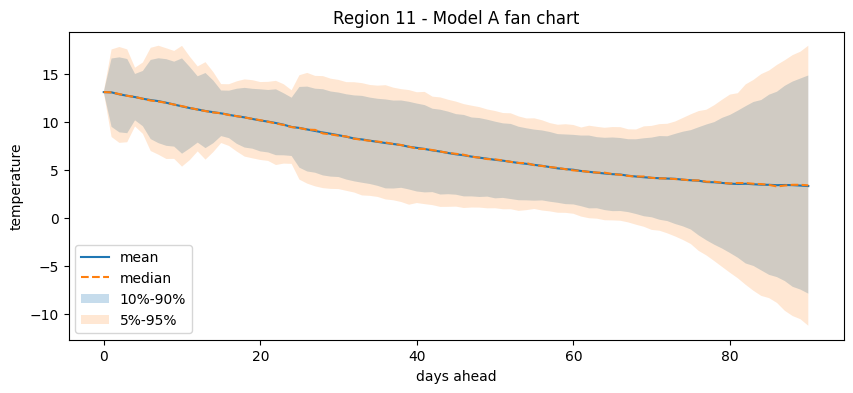

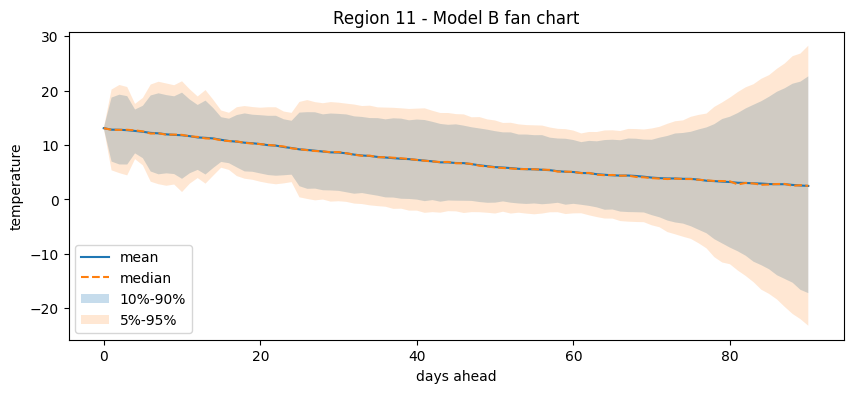

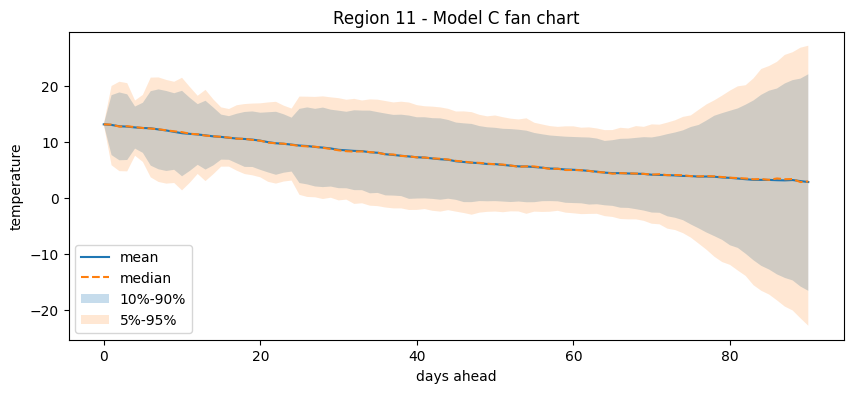

In [34]:
# ============================================================
# 1) FAN CHARTS
# ============================================================

def plot_fan(stats, title):
    x = np.arange(len(stats["mean"]))
    plt.figure(figsize=(10, 4))
    plt.plot(x, stats["mean"], label="mean")
    plt.plot(x, stats["q50"], linestyle="--", label="median")
    plt.fill_between(x, stats["q10"], stats["q90"], alpha=0.25, label="10%-90%")
    plt.fill_between(x, stats["q05"], stats["q95"], alpha=0.18, label="5%-95%")
    plt.xlabel("days ahead")
    plt.ylabel("temperature")
    plt.title(title)
    plt.legend()
    plt.show()

plot_fan(stats_A, f"Region {SIM_REGION} - Model A fan chart")
plot_fan(stats_B, f"Region {SIM_REGION} - Model B fan chart")
plot_fan(stats_C, f"Region {SIM_REGION} - Model C fan chart")

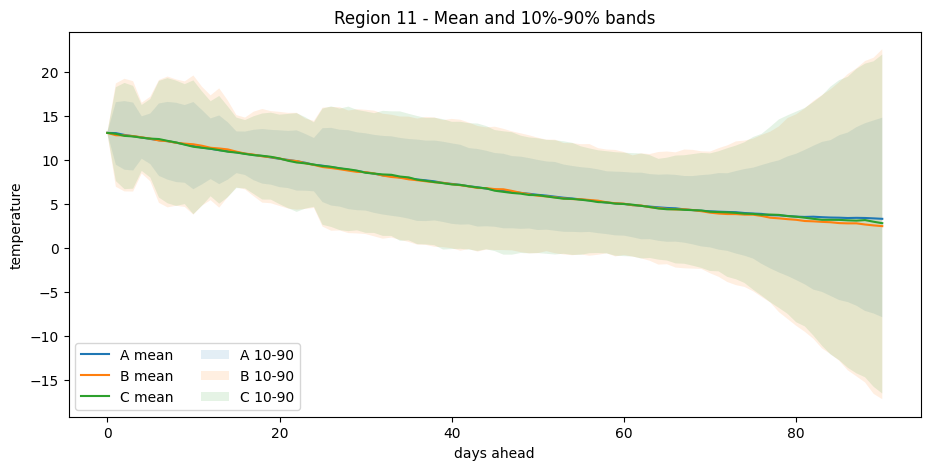

In [35]:
# ============================================================
# 2) OVERLAID FAN BANDS (easy direct comparison)
# ============================================================

x = np.arange(len(stats_A["mean"]))

plt.figure(figsize=(11, 5))
plt.plot(x, stats_A["mean"], label="A mean")
plt.plot(x, stats_B["mean"], label="B mean")
plt.plot(x, stats_C["mean"], label="C mean")

plt.fill_between(x, stats_A["q10"], stats_A["q90"], alpha=0.12, label="A 10-90")
plt.fill_between(x, stats_B["q10"], stats_B["q90"], alpha=0.12, label="B 10-90")
plt.fill_between(x, stats_C["q10"], stats_C["q90"], alpha=0.12, label="C 10-90")

plt.xlabel("days ahead")
plt.ylabel("temperature")
plt.title(f"Region {SIM_REGION} - Mean and 10%-90% bands")
plt.legend(ncol=2)
plt.show()

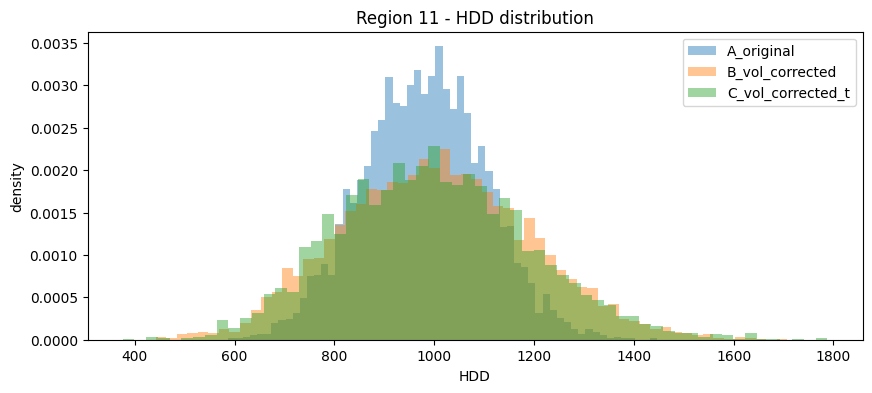

In [36]:
# ============================================================
# 3) HDD DISTRIBUTION COMPARISON
# ============================================================

hdd_A = hdd_values(T_paths_A, base_temp=BASE_TEMP)
hdd_B = hdd_values(T_paths_B, base_temp=BASE_TEMP)
hdd_C = hdd_values(T_paths_C, base_temp=BASE_TEMP)

plt.figure(figsize=(10, 4))
plt.hist(hdd_A, bins=60, alpha=0.45, density=True, label="A_original")
plt.hist(hdd_B, bins=60, alpha=0.45, density=True, label="B_vol_corrected")
plt.hist(hdd_C, bins=60, alpha=0.45, density=True, label="C_vol_corrected_t")
plt.xlabel("HDD")
plt.ylabel("density")
plt.title(f"Region {SIM_REGION} - HDD distribution")
plt.legend()
plt.show()

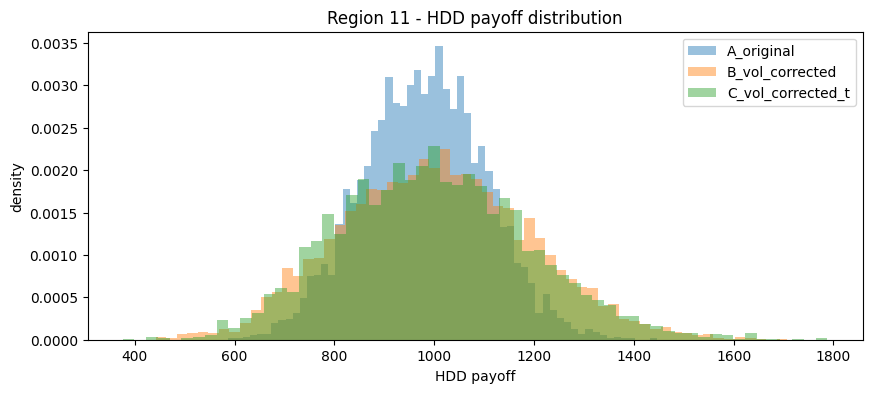

In [37]:
# ============================================================
# 4) PAYOFF DISTRIBUTION COMPARISON
# ============================================================

pay_A = payoff_values(hdd_A, tick_value=TICK_VALUE)
pay_B = payoff_values(hdd_B, tick_value=TICK_VALUE)
pay_C = payoff_values(hdd_C, tick_value=TICK_VALUE)

plt.figure(figsize=(10, 4))
plt.hist(pay_A, bins=60, alpha=0.45, density=True, label="A_original")
plt.hist(pay_B, bins=60, alpha=0.45, density=True, label="B_vol_corrected")
plt.hist(pay_C, bins=60, alpha=0.45, density=True, label="C_vol_corrected_t")
plt.xlabel("HDD payoff")
plt.ylabel("density")
plt.title(f"Region {SIM_REGION} - HDD payoff distribution")
plt.legend()
plt.show()

In [38]:
# ============================================================
# 5) EXTREME-TEMPERATURE TAIL PROBABILITIES
# ============================================================

thresholds_low = [-5, -10, -15]
thresholds_high = [25, 30, 35]

rows = []
for label, T in [("A_original", T_paths_A), ("B_vol_corrected", T_paths_B), ("C_vol_corrected_t", T_paths_C)]:
    row = {"model": label}
    for thr in thresholds_low:
        row[f"P(any day <= {thr})"] = float(np.mean(np.any(T[:, 1:] <= thr, axis=1)))
    for thr in thresholds_high:
        row[f"P(any day >= {thr})"] = float(np.mean(np.any(T[:, 1:] >= thr, axis=1)))
    rows.append(row)

tail_df = pd.DataFrame(rows)
tail_df

,model,P(any day <= -5),P(any day <= -10),P(any day <= -15),P(any day >= 25),P(any day >= 30),P(any day >= 35)
0,A_original,0.30250,0.10250,0.02650,0.00825,0.00075,0.00000
1,B_vol_corrected,0.71000,0.38025,0.21025,0.18600,0.06400,0.02575
2,C_vol_corrected_t,0.68425,0.35625,0.19275,0.20975,0.07275,0.02925


# Final model architecture

In [48]:
# ============================================================
# FINAL MODEL TRAINING SETUP
# Choose either:
#   USE_GLOBAL_ARCH = True   -> same NN architecture for all regions
#   USE_GLOBAL_ARCH = False  -> use best_config_per_region
# ============================================================

USE_GLOBAL_ARCH = True

# If using one global architecture for all regions:
FINAL_HIDDEN = 32
FINAL_ACTIVATION = "leakyrelu"
FINAL_N_LAYERS = 1

# Training hyperparameters
FINAL_EPOCHS = 2000
EVAL_EVERY = 25
EARLY_STOP_PATIENCE = 10
EARLY_STOP_MIN_DELTA = 1e-4
FINAL_LR = 1e-3
FINAL_KAPPA_MAX = 0.5
FINAL_WEIGHT_DECAY = 0.0
FINAL_GRAD_CLIP = 1.0

# Fixed split
train_end_date = pd.Timestamp("2014-12-31")
test_end_date = pd.Timestamp("2024-12-31")

FINAL_MODEL_DIR = "final_models_per_region"
os.makedirs(FINAL_MODEL_DIR, exist_ok=True)

In [50]:
# ============================================================
# HELPERS FOR FINAL TRAINING / DIAGNOSTICS
# ============================================================

from scipy.stats import t

def get_final_arch_for_region(region_id: int):
    if USE_GLOBAL_ARCH:
        return {
            "hidden": FINAL_HIDDEN,
            "activation": FINAL_ACTIVATION,
            "n_layers": FINAL_N_LAYERS,
        }
    else:
        row = best_config_per_region[best_config_per_region["region"] == region_id].iloc[0]
        return {
            "hidden": int(row["hidden"]),
            "activation": str(row["activation"]),
            "n_layers": int(row["n_layers"]),
        }

def prepare_region_data_final(region_id: int):
    art = region_artifacts[region_id]
    dfr = art["df"]

    x = np.asarray(art["x"], dtype=np.float32)

    x_mean = float(np.mean(x))
    x_std = float(np.std(x) + 1e-8)
    xz = ((x - x_mean) / x_std).astype(np.float32)

    doy_feat = doy_features(dfr["date"], harmonics=DOY_HARMONICS)
    X_in, x_t, x_tp1, idx_t = make_windows(xz, doy_feat, window=WINDOW)

    window_dates = dfr.loc[idx_t, "date"].reset_index(drop=True)

    train_mask = (window_dates <= train_end_date).values
    test_mask = ((window_dates > train_end_date) & (window_dates <= test_end_date)).values

    return {
        "dfr": dfr,
        "x": x,
        "x_mean": x_mean,
        "x_std": x_std,
        "xz": xz,
        "X_in": X_in,
        "x_t": x_t,
        "x_tp1": x_tp1,
        "idx_t": idx_t,
        "window_dates": window_dates,
        "train_mask": train_mask,
        "test_mask": test_mask,
    }

def estimate_student_df_from_residuals(z, df_grid=None):
    z = np.asarray(z, dtype=float)
    z = z[np.isfinite(z)]

    if df_grid is None:
        df_grid = np.concatenate([
            np.arange(3.0, 10.5, 0.5),
            np.arange(11.0, 31.0, 1.0),
            np.array([40.0, 60.0, 100.0])
        ])

    best_df = None
    best_nll = np.inf

    for df in df_grid:
        scale_to_unit_var = np.sqrt((df - 2.0) / df)
        ll = t.logpdf(z, df=df, loc=0.0, scale=scale_to_unit_var)
        nll = -np.sum(ll)
        if np.isfinite(nll) and nll < best_nll:
            best_nll = nll
            best_df = float(df)

    return best_df, best_nll

def final_interval_metrics(y_true, mean_pred, sigma_pred):
    zcrit = 1.6448536269514722
    lower = mean_pred - zcrit * sigma_pred
    upper = mean_pred + zcrit * sigma_pred
    covered = ((y_true >= lower) & (y_true <= upper)).astype(float)
    return {
        "picp_90": float(np.mean(covered)),
        "mpiw_90": float(np.mean(upper - lower)),
    }

In [ ]:
# ============================================================
# TRAIN FINAL MODEL A PER REGION
# ============================================================

final_models = {}
final_region_artifacts = {}
final_summary_rows = []


for r in regions:
    data = prepare_region_data_final(r)

    X_in = data["X_in"]
    x_t = data["x_t"]
    x_tp1 = data["x_tp1"]
    train_mask = data["train_mask"]
    test_mask = data["test_mask"]

    if train_mask.sum() == 0 or test_mask.sum() == 0:
        final_summary_rows.append({
            "region": r,
            "status": "skipped (bad split)"
        })
        continue

    X_train = torch.tensor(X_in[train_mask], dtype=torch.float32, device=device)
    x_t_train = torch.tensor(x_t[train_mask], dtype=torch.float32, device=device)
    x_tp1_train = torch.tensor(x_tp1[train_mask], dtype=torch.float32, device=device)

    X_test = torch.tensor(X_in[test_mask], dtype=torch.float32, device=device)
    x_t_test = x_t[test_mask]
    x_tp1_test = x_tp1[test_mask]

    arch = get_final_arch_for_region(r)

    model = CalibNetFlexible(
        in_dim=X_train.shape[1],
        hidden=arch["hidden"],
        activation=arch["activation"],
        n_layers=arch["n_layers"],
        kappa_max=FINAL_KAPPA_MAX
    ).to(device)

    opt = torch.optim.Adam(
        model.parameters(),
        lr=FINAL_LR,
        weight_decay=FINAL_WEIGHT_DECAY
    )

    train_curve = []
    test_curve = []
    epochs_logged = []

    for epoch in range(1, FINAL_EPOCHS + 1):
    model.train()
    kappa, sigma = model(X_train)
    loss = ou_nll_euler_safe(x_t_train, x_tp1_train, kappa, sigma, dt=DT)

    opt.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), FINAL_GRAD_CLIP)
    opt.step()

    if epoch % 50 == 0 or epoch == 1:
        model.eval()
        with torch.no_grad():
            kappa_te, sigma_te = model(X_test)
            mean_te = x_t_test - kappa_te.detach().cpu().numpy() * x_t_test * DT
            var_te = np.clip((sigma_te.detach().cpu().numpy() ** 2) * DT, 1e-6, None)
            test_nll = np.mean(0.5 * (np.log(var_te) + ((x_tp1_test - mean_te) ** 2) / var_te))

        train_curve.append(float(loss.item()))
        test_curve.append(float(test_nll))
        epochs_logged.append(epoch)

    # Final evaluation
    model.eval()
    with torch.no_grad():
        kappa_te, sigma_te = model(X_test)

    kappa_te = kappa_te.detach().cpu().numpy()
    sigma_te = sigma_te.detach().cpu().numpy()

    mean_pred_z = x_t_test - kappa_te * x_t_test * DT

    x_mean = data["x_mean"]
    x_std = data["x_std"]

    y_true = x_tp1_test * x_std + x_mean
    y_pred = mean_pred_z * x_std + x_mean
    sigma_pred = sigma_te * x_std

    mae = float(np.mean(np.abs(y_true - y_pred)))
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2) + 1e-12
    r2 = float(1.0 - ss_res / ss_tot)
    corr = float(np.corrcoef(y_true, y_pred)[0, 1])

    ivl = final_interval_metrics(y_true, y_pred, sigma_pred)
    z_A = (y_true - y_pred) / (sigma_pred + 1e-12)

    # Save model + artifacts
    model_path = os.path.join(FINAL_MODEL_DIR, f"final_model_region_{r}.pt")
    torch.save({
        "state_dict": model.state_dict(),
        "region": r,
        "hidden": arch["hidden"],
        "activation": arch["activation"],
        "n_layers": arch["n_layers"],
        "kappa_max": FINAL_KAPPA_MAX,
        "window": WINDOW,
        "doy_harmonics": DOY_HARMONICS,
        "x_mean": x_mean,
        "x_std": x_std,
    }, model_path)

    final_models[r] = model
    final_region_artifacts[r] = {
        **data,
        "model_path": model_path,
        "arch": arch,
        "train_curve": train_curve,
        "test_curve": test_curve,
        "epochs_logged": epochs_logged,
        "y_true_test": y_true,
        "y_pred_test": y_pred,
        "sigma_pred_test": sigma_pred,
        "z_A_test": z_A,
    }

    final_summary_rows.append({
        "region": r,
        "status": "ok",
        "hidden": arch["hidden"],
        "activation": arch["activation"],
        "n_layers": arch["n_layers"],
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
        "corr": corr,
        "picp_90": ivl["picp_90"],
        "mpiw_90": ivl["mpiw_90"],
        "z_mean": float(np.mean(z_A)),
        "z_std": float(np.std(z_A)),
        "z_skew": float(compute_skewness(z_A)),
        "z_kurtosis": float(compute_kurtosis(z_A)),
        "model_path": model_path,
    })

final_summary = pd.DataFrame(final_summary_rows).sort_values("region").reset_index(drop=True)
final_summary

,region,status,hidden,activation,n_layers,mae,rmse,r2,corr,picp_90,mpiw_90,z_mean,z_std,z_skew,z_kurtosis,model_path
0,11,ok,32,leakyrelu,1,1.606115,2.016404,0.607566,0.779767,0.881709,6.513941,0.031149,1.069200,0.226050,3.463810,final_models_per_region/final_model_region_11.pt
1,24,ok,32,leakyrelu,1,1.610492,2.011953,0.614902,0.784439,0.882256,6.567572,0.027145,1.083295,0.121220,3.819222,final_models_per_region/final_model_region_24.pt
2,27,ok,32,leakyrelu,1,1.540578,1.951199,0.647861,0.805393,0.895919,6.780518,0.012362,1.061718,-0.208666,4.966633,final_models_per_region/final_model_region_27.pt
3,28,ok,32,leakyrelu,1,1.292816,1.656469,0.615830,0.785138,0.865553,5.205839,0.055057,1.157708,0.384893,4.642459,final_models_per_region/final_model_region_28.pt
4,32,ok,32,leakyrelu,1,1.423575,1.811219,0.621635,0.788875,0.893209,6.243235,0.033321,1.063786,0.342210,4.626914,final_models_per_region/final_model_region_32.pt
5,44,ok,32,leakyrelu,1,1.442647,1.835003,0.680348,0.825016,0.898412,6.290423,0.028074,1.018609,0.248950,4.912162,final_models_per_region/final_model_region_44.pt
6,52,ok,32,leakyrelu,1,1.477648,1.866588,0.600623,0.775253,0.894304,6.271330,0.033664,1.031423,0.235170,3.658799,final_models_per_region/final_model_region_52.pt
7,53,ok,32,leakyrelu,1,1.204795,1.533761,0.594631,0.771318,0.882256,4.954427,0.004228,1.093663,0.329257,4.465063,final_models_per_region/final_model_region_53.pt


In [52]:
# ============================================================
# FINAL MODEL B: VOLATILITY CORRECTION
# ============================================================

final_vol_correction = {}

for _, row in final_summary.iterrows():
    if row["status"] == "ok":
        final_vol_correction[int(row["region"])] = float(row["z_std"])

final_vol_corr_df = pd.DataFrame({
    "region": list(final_vol_correction.keys()),
    "vol_multiplier": list(final_vol_correction.values())
}).sort_values("region").reset_index(drop=True)

final_vol_corr_df

,region,vol_multiplier
0,11,1.069200
1,24,1.083295
2,27,1.061718
3,28,1.157708
4,32,1.063786
5,44,1.018609
6,52,1.031423
7,53,1.093663


In [53]:
# ============================================================
# FINAL MODEL C: ESTIMATE REGION-SPECIFIC STUDENT-t DF
# from Model B residuals
# ============================================================

final_student_df_rows = []

for r in sorted([rr for rr in final_region_artifacts.keys() if rr in final_models and rr in final_vol_correction]):
    art = final_region_artifacts[r]
    model = final_models[r]

    X_in = art["X_in"]
    x_t = art["x_t"]
    x_tp1 = art["x_tp1"]
    test_mask = art["test_mask"]

    X_test = torch.tensor(X_in[test_mask], dtype=torch.float32, device=device)
    x_t_test = x_t[test_mask]
    x_tp1_test = x_tp1[test_mask]

    model.eval()
    with torch.no_grad():
        kappa_te, sigma_te = model(X_test)

    kappa_te = kappa_te.detach().cpu().numpy()
    sigma_te = sigma_te.detach().cpu().numpy()

    vol_mult = float(final_vol_correction[r])
    sigma_te_corr = vol_mult * sigma_te

    mean_pred_z = x_t_test - kappa_te * x_t_test * DT
    z_B = (x_tp1_test - mean_pred_z) / (sigma_te_corr + 1e-12)

    best_df, best_nll = estimate_student_df_from_residuals(z_B)

    final_student_df_rows.append({
        "region": r,
        "student_t_df_hat": best_df,
        "student_t_nll": best_nll,
        "n_test_obs": int(len(z_B)),
        "z_mean_B": float(np.mean(z_B)),
        "z_std_B": float(np.std(z_B)),
        "z_kurtosis_B": float(compute_kurtosis(z_B)),
    })

final_student_df_df = pd.DataFrame(final_student_df_rows).sort_values("region").reset_index(drop=True)
final_student_df_df

,region,student_t_df_hat,student_t_nll,n_test_obs,z_mean_B,z_std_B,z_kurtosis_B
0,11,16.0,5171.813194,3652,0.029133,1.0,3.463810
1,24,11.0,5156.245724,3652,0.025058,1.0,3.819222
2,27,7.0,5105.246493,3651,0.011644,1.0,4.966631
3,28,6.0,5093.079275,3652,0.047557,1.0,4.642461
4,32,7.0,5111.561803,3652,0.031323,1.0,4.626914
5,44,10.0,5137.989167,3652,0.027561,1.0,4.912163
6,52,12.0,5161.147963,3652,0.032639,1.0,3.658799
7,53,8.5,5129.612763,3652,0.003866,1.0,4.465063


In [54]:
# ============================================================
# FINAL LOOKUPS
# ============================================================

final_student_df_lookup = dict(
    zip(final_student_df_df["region"].astype(int), final_student_df_df["student_t_df_hat"].astype(float))
)

final_arch_lookup = {
    int(row["region"]): {
        "hidden": int(row["hidden"]),
        "activation": str(row["activation"]),
        "n_layers": int(row["n_layers"]),
    }
    for _, row in final_summary.iterrows()
    if row["status"] == "ok"
}

final_student_df_lookup, final_arch_lookup

({11: 16.0, 24: 11.0, 27: 7.0, 28: 6.0, 32: 7.0, 44: 10.0, 52: 12.0, 53: 8.5},
 {11: {'hidden': 32, 'activation': 'leakyrelu', 'n_layers': 1},
  24: {'hidden': 32, 'activation': 'leakyrelu', 'n_layers': 1},
  27: {'hidden': 32, 'activation': 'leakyrelu', 'n_layers': 1},
  28: {'hidden': 32, 'activation': 'leakyrelu', 'n_layers': 1},
  32: {'hidden': 32, 'activation': 'leakyrelu', 'n_layers': 1},
  44: {'hidden': 32, 'activation': 'leakyrelu', 'n_layers': 1},
  52: {'hidden': 32, 'activation': 'leakyrelu', 'n_layers': 1},
  53: {'hidden': 32, 'activation': 'leakyrelu', 'n_layers': 1}})

In [55]:
# ============================================================
# FINAL SIMULATION FUNCTION:
# Model C = final NN + volatility correction + region-specific Student-t df
# ============================================================

def simulate_final_modelC(region_id: int, start_index: int, sim: SimConfigBC):
    art = final_region_artifacts[region_id]
    model = final_models[region_id]

    dfr = art["dfr"].copy()
    x_mean = art["x_mean"]
    x_std = art["x_std"]

    vol_mult = float(final_vol_correction[region_id])
    df_t = float(final_student_df_lookup[region_id])

    # seasonal mean from original region artifact
    beta = region_artifacts[region_id]["beta"]

    x0 = float(art["x"][start_index])
    x0z = (x0 - x_mean) / x_std

    start_date = dfr.loc[start_index, "date"]
    dates = pd.date_range(start_date, periods=sim.horizon_days + 1, freq="D")

    X_design = design_matrix_seasonality(pd.Series(dates), K=K_HARMONICS, include_trend=True)
    s_future = X_design @ beta

    xz_series = ((art["x"] - x_mean) / x_std).astype(np.float32)
    hist = xz_series[max(0, start_index - WINDOW):start_index]
    if len(hist) < WINDOW:
        hist = np.pad(hist, (WINDOW - len(hist), 0), mode="edge")

    X_paths_z = np.zeros((sim.n_paths, sim.horizon_days + 1), dtype=np.float32)
    T_paths = np.zeros((sim.n_paths, sim.horizon_days + 1), dtype=np.float32)

    X_paths_z[:, 0] = x0z
    T_paths[:, 0] = s_future[0] + x0

    t_scale = np.sqrt((df_t - 2.0) / df_t)

    for t_idx in range(sim.horizon_days):
        feat = doy_features(pd.Series([dates[t_idx]]), harmonics=DOY_HARMONICS).astype(np.float32).reshape(-1)
        inp = np.concatenate([hist[-WINDOW:], feat], axis=0)[None, :]
        inp_t = torch.tensor(inp, dtype=torch.float32, device=device)

        with torch.no_grad():
            kappa_t, sigma_t = model(inp_t)

        kappa_t = float(kappa_t.item())
        sigma_t = float(sigma_t.item())
        sigma_t_corr = vol_mult * sigma_t

        eps = (np.random.standard_t(df=df_t, size=sim.n_paths) * t_scale).astype(np.float32)

        x_next_z = (
            X_paths_z[:, t_idx]
            - kappa_t * X_paths_z[:, t_idx] * sim.dt
            + sigma_t_corr * np.sqrt(sim.dt) * eps
        )

        X_paths_z[:, t_idx + 1] = x_next_z
        x_next = x_next_z * x_std + x_mean
        T_paths[:, t_idx + 1] = s_future[t_idx + 1] + x_next

        hist = np.append(hist, x_next_z.mean())

    return T_paths

In [ ]:
# ============================================================
# FINAL COMPACT SUMMARY
# ============================================================

final_report = final_summary.merge(
    final_vol_corr_df, on="region", how="left"
).merge(
    final_student_df_df[["region", "student_t_df_hat"]], on="region", how="left"
)

final_report[[
    "region",
    "hidden", "activation", "n_layers",
    "mae", "rmse", "r2", "corr",
    "picp_90", "z_std", "z_kurtosis",
    "vol_multiplier", "student_t_df_hat"
]]

,region,hidden,activation,n_layers,mae,rmse,r2,corr,picp_90,z_std,z_kurtosis,vol_multiplier,student_t_df_hat
0,11,32,leakyrelu,1,1.606115,2.016404,0.607566,0.779767,0.881709,1.069200,3.463810,1.069200,16.0
1,24,32,leakyrelu,1,1.610492,2.011953,0.614902,0.784439,0.882256,1.083295,3.819222,1.083295,11.0
2,27,32,leakyrelu,1,1.540578,1.951199,0.647861,0.805393,0.895919,1.061718,4.966633,1.061718,7.0
3,28,32,leakyrelu,1,1.292816,1.656469,0.615830,0.785138,0.865553,1.157708,4.642459,1.157708,6.0
4,32,32,leakyrelu,1,1.423575,1.811219,0.621635,0.788875,0.893209,1.063786,4.626914,1.063786,7.0
5,44,32,leakyrelu,1,1.442647,1.835003,0.680348,0.825016,0.898412,1.018609,4.912162,1.018609,10.0
6,52,32,leakyrelu,1,1.477648,1.866588,0.600623,0.775253,0.894304,1.031423,3.658799,1.031423,12.0
7,53,32,leakyrelu,1,1.204795,1.533761,0.594631,0.771318,0.882256,1.093663,4.465063,1.093663,8.5
